# Caso de estudio: DC-SBM en Star Wars II

Esta notebook replica el ejercicio de inferencia estadística de comunidades para la red de personajes de **Star Wars II: Attack of the Clones**. La fuente es el archivo

```python
PROJECT_ROOT = find_project_root()
folder = PROJECT_ROOT / "data/dataverse/gexf"
movie_id = 774
fp = folder / f"{movie_id}.gexf"
```

El objetivo no es solamente colorear una red, sino interpretar el resultado como un **modelo probabilístico de interacción**: queremos saber si la red de personajes se organiza como grupos densos, como roles que se conectan entre sí, o como una mezcla de ambas cosas.

Seguimos la notación del apunte `416_metodos_inferencia_estadistica.md`: los grupos son $1,\ldots,q$, la etiqueta latente del nodo $i$ es $g_i$, los parámetros de grado esperado son $c_i$, y la matriz de intensidades entre comunidades es

$$
\Omega=(\omega_{rs})_{r,s=1}^q.
$$

Para una matriz de adyacencia no dirigida $A$, definimos

$$
k_i=\sum_j A_{ij},
\qquad
2m=\sum_i k_i,
$$

así como los agregados por bloque

$$
\kappa_r=\sum_i \delta_{g_i r} c_i,
\qquad
m_{rs}=\sum_{ij}\delta_{g_i r}\delta_{g_j s}A_{ij}.
$$

Después de maximizar la verosimilitud respecto a los parámetros continuos, se obtiene

$$
\hat c_i=k_i,
\qquad
\hat\omega_{rs}=\frac{2m\,m_{rs}}{\kappa_r\kappa_s}.
$$

La partición se elige maximizando la log-verosimilitud perfilada

$$
L(g)=\frac12\sum_{r,s}m_{rs}\log\left(\frac{m_{rs}}{\kappa_r\kappa_s}\right)+\text{constantes}.
$$

Los términos con $m_{rs}=0$ se toman como cero.

In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List

import math
import random

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

OUT_DIR = Path("outputs_sbm_sw")
OUT_DIR.mkdir(exist_ok=True)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2",
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#D0D4DA",
        "grid.color": "#E7EAF0",
        "grid.linewidth": 0.8,
        "font.family": "DejaVu Sans",
    },
)

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

## 1. Carga de datos

El archivo GEXF contiene la red de personajes de la película con `movie_id=774`. Cada nodo tiene un identificador numérico, pero también trae un atributo `label` con el nombre del personaje. Para que las tablas y figuras sean interpretables, relabelamos la red usando esos nombres.

Si el GEXF tuviera multiaristas o pesos, aquí lo convertimos a un grafo simple no dirigido. En esta red las aristas representan coaparición o interacción entre personajes; por eso la dirección no es parte del modelo.

In [2]:
# ============================================================
# 2. Datos de la red
# ============================================================
def find_project_root(start: Path | None = None) -> Path:
    # Busca hacia arriba hasta encontrar la raíz del proyecto.
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "data").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("No se encontró la raíz del proyecto con carpetas data/ y notebooks/.")


PROJECT_ROOT = find_project_root()
folder = PROJECT_ROOT / "data/dataverse/gexf"
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G_raw = nx.read_gexf(fp)
if G_raw.is_directed():
    G_raw = nx.Graph(G_raw)

label_map = {}
seen = {}
for node, data in G_raw.nodes(data=True):
    label = str(data.get("label", node)).strip()
    if label in seen:
        seen[label] += 1
        label = f"{label}_{seen[label]}"
    else:
        seen[label] = 1
    label_map[node] = label

G = nx.relabel_nodes(G_raw, label_map).copy()
G.remove_edges_from(nx.selfloop_edges(G))

for node, data in G.nodes(data=True):
    data["name"] = node

print("Archivo:", fp)
print("Grafo no dirigido | Nodos:", G.number_of_nodes(), "| Aristas:", G.number_of_edges())
print("Componentes conexas:", [len(c) for c in nx.connected_components(G)])
print("Densidad:", round(nx.density(G), 4))

Archivo: C:\Users\herie\git\LDS1121-Complex-Networks\data\dataverse\gexf\774.gexf
Grafo no dirigido | Nodos: 47 | Aristas: 148
Componentes conexas: [47]
Densidad: 0.1369


## 2. Minired de personajes centrales

Además de la red completa, analizamos una minired inducida por personajes con grado al menos $3$:

$$
V_{\text{mini}}=\{i\in V:\; k_i\ge 3\},
\qquad
G_{\text{mini}}=G[V_{\text{mini}}].
$$

La razón es narrativa y estadística. Los personajes de grado bajo suelen aparecer en escenas muy locales; son importantes para la película, pero pueden introducir ruido periférico en la inferencia. La minired deja el núcleo de personajes recurrentes y permite revisar si la estructura comunitaria principal se mantiene.

In [3]:
# ============================================================
# 3. Minired editable
# ============================================================
MINIRED_MODE = "degree_at_least_3"  # opciones: "degree_at_least_3" o "manual"

mini_nodes_manual = [
    "ANAKIN", "OBI-WAN", "PADME", "AMIDALA", "PALPATINE", "YODA", "MACE WINDU",
    "COUNT DOOKU", "JANGO FETT", "BOBA FETT", "OWEN", "BERU", "CLIEGG"
]

if MINIRED_MODE == "degree_at_least_3":
    mini_nodes = [node for node, degree in G.degree() if degree >= 3]
elif MINIRED_MODE == "manual":
    mini_nodes = [node for node in mini_nodes_manual if node in G]
else:
    raise ValueError("MINIRED_MODE debe ser 'degree_at_least_3' o 'manual'.")

G_mini = G.subgraph(mini_nodes).copy()

print("Minired | Nodos:", G_mini.number_of_nodes(), "| Aristas:", G_mini.number_of_edges())
print("Componentes conexas en minired:", [len(c) for c in nx.connected_components(G_mini)])
print("Nodos removidos por baja conectividad:", sorted(set(G.nodes()) - set(G_mini.nodes())))

Minired | Nodos: 34 | Aristas: 128
Componentes conexas en minired: [34]
Nodos removidos por baja conectividad: ['CHILDREN', 'DARTH SIDIOUS', 'DEXTER JETTSTER', 'DOOKU', 'ELAN', 'HERMIONE BAGWA', 'JOCASTA NU', 'LAMA SU', 'PK-4', 'RYOO & POOJA', 'SHMI', 'WATTO', 'ZAM WESSEL']


## 3. Resumen estructural inicial

Antes del DC-SBM conviene mirar grados, densidad y componentes. El modelo corregido por grado separa dos efectos:

1. **popularidad o centralidad individual**, capturada por $\hat c_i=k_i$;
2. **estructura entre grupos**, capturada por $\hat\omega_{rs}$.

En una red narrativa esperamos nodos muy centrales, como protagonistas o antagonistas, que conectan varias subtramas. El DC-SBM evita que esos nodos definan comunidades solo por tener grado alto: pregunta si, después de corregir por grado, las aristas se concentran dentro o entre bloques específicos.

In [4]:
# ============================================================
# 4. Resúmenes de red
# ============================================================
def graph_summary(Gx: nx.Graph, name: str) -> pd.Series:
    degrees = dict(Gx.degree())
    components = [len(c) for c in nx.connected_components(Gx)]
    return pd.Series({
        "red": name,
        "nodos": Gx.number_of_nodes(),
        "aristas": Gx.number_of_edges(),
        "densidad": nx.density(Gx),
        "grado_promedio": np.mean(list(degrees.values())) if degrees else 0,
        "grado_max": max(degrees.values()) if degrees else 0,
        "componentes": len(components),
        "tamanos_componentes": components,
    })


def degree_table(Gx: nx.Graph) -> pd.DataFrame:
    rows = []
    for node, degree in Gx.degree():
        rows.append({
            "personaje": node,
            "grado": degree,
            "componente": next(i for i, comp in enumerate(nx.connected_components(Gx)) if node in comp),
        })
    return pd.DataFrame(rows).sort_values(["grado", "personaje"], ascending=[False, True]).reset_index(drop=True)


summary_df = pd.DataFrame([graph_summary(G, "G completa"), graph_summary(G_mini, "G_mini")])
display(summary_df)
summary_df.to_csv(OUT_DIR / "resumen_redes.csv", index=False)

display(Markdown("### Top grados: red completa"))
deg_full = degree_table(G)
display(deg_full.head(15))
deg_full.to_csv(OUT_DIR / "grados_G.csv", index=False)

display(Markdown("### Top grados: minired"))
deg_mini = degree_table(G_mini)
display(deg_mini.head(15))
deg_mini.to_csv(OUT_DIR / "grados_G_mini.csv", index=False)

,red,nodos,aristas,densidad,grado_promedio,grado_max,componentes,tamanos_componentes
0,G completa,47,148,0.136910,6.297872,30,1,[47]
1,G_mini,34,128,0.228164,7.529412,28,1,[34]


### Top grados: red completa

,personaje,grado,componente
0,PADMÉ,30,0
1,OBI-WAN,29,0
2,ANAKIN,24,0
3,YODA,14,0
4,MACE WINDU,13,0
5,JAR JAR,11,0
6,PALPATINE,11,0
7,MAS AMEDDA,10,0
8,SENATOR ASK AAK,10,0
9,BAIL ORGANA,9,0


### Top grados: minired

,personaje,grado,componente
0,PADMÉ,28,0
1,OBI-WAN,21,0
2,ANAKIN,19,0
3,MACE WINDU,13,0
4,YODA,13,0
5,JAR JAR,11,0
6,PALPATINE,11,0
7,MAS AMEDDA,10,0
8,SENATOR ASK AAK,10,0
9,BAIL ORGANA,9,0


## 4. Modelo DC-SBM perfilado

Para una asignación $g$, el modelo Poisson del apunte usa media

$$
\omega_{g_i g_j}\frac{c_i c_j}{2m}.
$$

Al maximizar respecto a $c_i$ y $\omega_{rs}$ se obtiene

$$
\hat c_i=k_i,
\qquad
\hat\omega_{rs}=\frac{2m\,m_{rs}}{\kappa_r\kappa_s}.
$$

Sustituimos estos estimadores en $L(g)$ y buscamos la asignación de grupos que maximiza la log-verosimilitud perfilada. En el código usamos etiquetas Python $0,\ldots,q-1$, pero en la interpretación matemática se traducen como grupos $1,\ldots,q$.

In [5]:
# ============================================================
# 5. Implementación de DC-SBM perfilado
# ============================================================
@dataclass
class DCSBMFit:
    graph_name: str
    q: int
    labels: Dict[str, int]
    communities: Dict[int, List[str]]
    L: float
    bic_like: float
    omega: pd.DataFrame
    M: pd.DataFrame
    kappa: pd.Series
    modularity: float


def _nodes_and_adjacency(Gx: nx.Graph) -> tuple[list[str], np.ndarray, np.ndarray]:
    nodes = list(Gx.nodes())
    A = nx.to_numpy_array(Gx, nodelist=nodes, dtype=float)
    degrees = A.sum(axis=1)
    return nodes, A, degrees


def _renumber_labels(labels: np.ndarray) -> np.ndarray:
    unique = sorted(set(labels.tolist()))
    mapping = {old: new for new, old in enumerate(unique)}
    return np.array([mapping[x] for x in labels], dtype=int)


def _nonempty_random_labels(n: int, q: int, rng: np.random.Generator) -> np.ndarray:
    if q > n:
        raise ValueError("q no puede exceder el número de nodos.")
    labels = np.empty(n, dtype=int)
    labels[:q] = np.arange(q)
    if n > q:
        labels[q:] = rng.integers(0, q, size=n - q)
    rng.shuffle(labels)
    return labels


def block_matrices(A: np.ndarray, degrees: np.ndarray, labels: np.ndarray, q: int) -> tuple[np.ndarray, np.ndarray]:
    S = np.zeros((len(labels), q), dtype=float)
    S[np.arange(len(labels)), labels] = 1.0
    M = S.T @ A @ S
    kappa = S.T @ degrees
    return M, kappa


def profile_likelihood(A: np.ndarray, degrees: np.ndarray, labels: np.ndarray, q: int) -> float:
    M, kappa = block_matrices(A, degrees, labels, q)
    denom = np.outer(kappa, kappa)
    mask = (M > 0) & (denom > 0)
    value = 0.5 * np.sum(M[mask] * np.log(M[mask] / denom[mask]))
    return float(value)


def bic_like_score(L: float, q: int, m: int) -> float:
    effective_omega_params = max(1, q * (q + 1) // 2 - q)
    sample_size = max(2, 2 * m)
    return float(-2 * L + effective_omega_params * math.log(sample_size))


def greedy_optimize_labels(
    A: np.ndarray,
    degrees: np.ndarray,
    q: int,
    initial_labels: np.ndarray,
    rng: np.random.Generator,
    max_iter: int = 45,
) -> tuple[np.ndarray, float]:
    labels = _renumber_labels(initial_labels.copy())
    if len(set(labels.tolist())) != q:
        labels = _nonempty_random_labels(len(labels), q, rng)

    current_L = profile_likelihood(A, degrees, labels, q)
    n = len(labels)

    for _ in range(max_iter):
        improved = False
        for i in rng.permutation(n):
            old = labels[i]
            counts = np.bincount(labels, minlength=q)
            if counts[old] <= 1:
                continue

            best_label = old
            best_L = current_L

            for new in range(q):
                if new == old:
                    continue
                trial = labels.copy()
                trial[i] = new
                trial = _renumber_labels(trial)
                if len(set(trial.tolist())) != q:
                    continue
                trial_L = profile_likelihood(A, degrees, trial, q)
                if trial_L > best_L + 1e-12:
                    best_L = trial_L
                    best_label = new

            if best_label != old:
                labels[i] = best_label
                labels = _renumber_labels(labels)
                current_L = best_L
                improved = True

        if not improved:
            break

    return labels, current_L


def fit_dc_sbm(
    Gx: nx.Graph,
    graph_name: str,
    q: int,
    n_starts: int = 80,
    seed: int = RANDOM_SEED,
) -> DCSBMFit:
    nodes, A, degrees = _nodes_and_adjacency(Gx)
    rng = np.random.default_rng(seed)

    best_labels = None
    best_L = -np.inf
    for _ in range(n_starts):
        init = _nonempty_random_labels(len(nodes), q, rng)
        labels, L = greedy_optimize_labels(A, degrees, q, init, rng)
        if L > best_L:
            best_L = L
            best_labels = labels.copy()

    assert best_labels is not None
    best_labels = _renumber_labels(best_labels)
    M, kappa = block_matrices(A, degrees, best_labels, q)
    two_m = degrees.sum()

    with np.errstate(divide="ignore", invalid="ignore"):
        omega = two_m * M / np.outer(kappa, kappa)
    omega = np.nan_to_num(omega, nan=0.0, posinf=0.0, neginf=0.0)

    labels_dict = {node: int(label) for node, label in zip(nodes, best_labels)}
    communities = {
        r: sorted([node for node, label in labels_dict.items() if label == r])
        for r in range(q)
    }

    comm_sets = [set(v) for v in communities.values()]
    modularity = nx.algorithms.community.quality.modularity(Gx, comm_sets)

    idx = [f"C{r}" for r in range(q)]
    return DCSBMFit(
        graph_name=graph_name,
        q=q,
        labels=labels_dict,
        communities=communities,
        L=best_L,
        bic_like=bic_like_score(best_L, q, Gx.number_of_edges()),
        omega=pd.DataFrame(omega, index=idx, columns=idx),
        M=pd.DataFrame(M, index=idx, columns=idx),
        kappa=pd.Series(kappa, index=idx, name="kappa"),
        modularity=float(modularity),
    )


def sweep_q(
    Gx: nx.Graph,
    graph_name: str,
    q_values: Iterable[int],
    n_starts: int = 80,
    seed: int = RANDOM_SEED,
) -> tuple[pd.DataFrame, Dict[int, DCSBMFit]]:
    fits: Dict[int, DCSBMFit] = {}
    rows = []
    for q in q_values:
        fit = fit_dc_sbm(Gx, graph_name, q=q, n_starts=n_starts, seed=seed + 1009 * q)
        fits[q] = fit
        rows.append({
            "red": graph_name,
            "q": q,
            "L_perfilada": fit.L,
            "BIC_like_menor_mejor": fit.bic_like,
            "modularidad_diagnostica": fit.modularity,
        })
    return pd.DataFrame(rows), fits

## 5. Barrido de $q$

Probamos varios valores de $q$. La verosimilitud perfilada tiende a mejorar al aumentar el número de bloques, así que también usamos

$$
\operatorname{BIC}_{\text{like}}(q)
=-2\hat L_q+p_q\log(2m),
\qquad
p_q\approx \frac{q(q+1)}2-q.
$$

El BIC-like no es una verdad absoluta: es una regla práctica para no escoger automáticamente el $q$ más grande. La interpretación final debe revisar si los bloques elegidos tienen sentido narrativo y estadístico.

In [6]:
# ============================================================
# 6. Ajuste en red completa y minired
# ============================================================
q_values_full = range(2, min(9, G.number_of_nodes()))
q_values_mini = range(2, min(8, G_mini.number_of_nodes()))

N_STARTS = 80

full_sweep, full_fits = sweep_q(G, "G completa", q_values_full, n_starts=N_STARTS)
mini_sweep, mini_fits = sweep_q(G_mini, "G_mini", q_values_mini, n_starts=N_STARTS)

sweep_df = pd.concat([full_sweep, mini_sweep], ignore_index=True)
display(sweep_df)
sweep_df.to_csv(OUT_DIR / "barrido_q_dc_sbm.csv", index=False)

best_q_full = int(full_sweep.sort_values("BIC_like_menor_mejor").iloc[0]["q"])
best_q_mini = int(mini_sweep.sort_values("BIC_like_menor_mejor").iloc[0]["q"])

fit_full = full_fits[best_q_full]
fit_mini = mini_fits[best_q_mini]

print(f"Mejor q por BIC-like para G completa: q={best_q_full}")
print(f"Mejor q por BIC-like para G_mini: q={best_q_mini}")

,red,q,L_perfilada,BIC_like_menor_mejor,modularidad_diagnostica
0,G completa,2,-1386.926970,2779.544300,0.247538
1,G completa,3,-1361.019522,2739.110123,0.124935
2,G completa,4,-1338.740623,2711.623402,0.182502
3,G completa,5,-1320.584492,2698.072580,0.211783
4,G completa,6,-1305.318246,2695.991884,0.146013
5,G completa,7,-1293.018119,2705.533787,0.117030
6,G completa,8,-1276.739161,2712.808387,0.145214
7,G_mini,2,-1228.972944,2463.491065,0.250681
8,G_mini,3,-1206.780725,2430.196982,0.114089
9,G_mini,4,-1187.248048,2407.767161,0.175294


Mejor q por BIC-like para G completa: q=6
Mejor q por BIC-like para G_mini: q=5


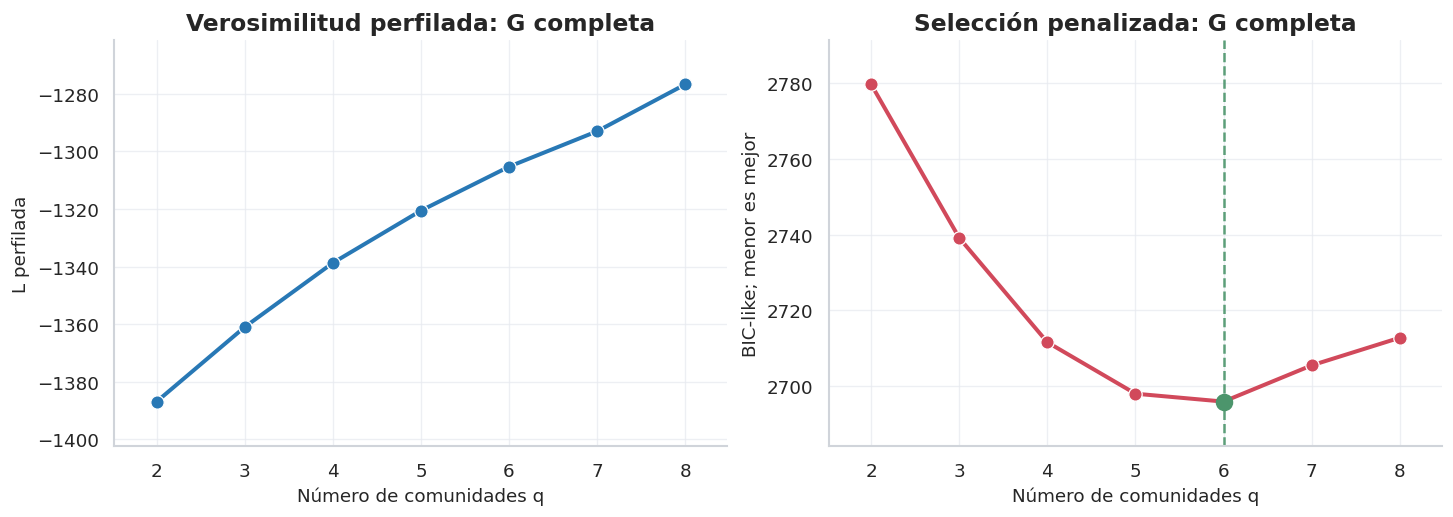

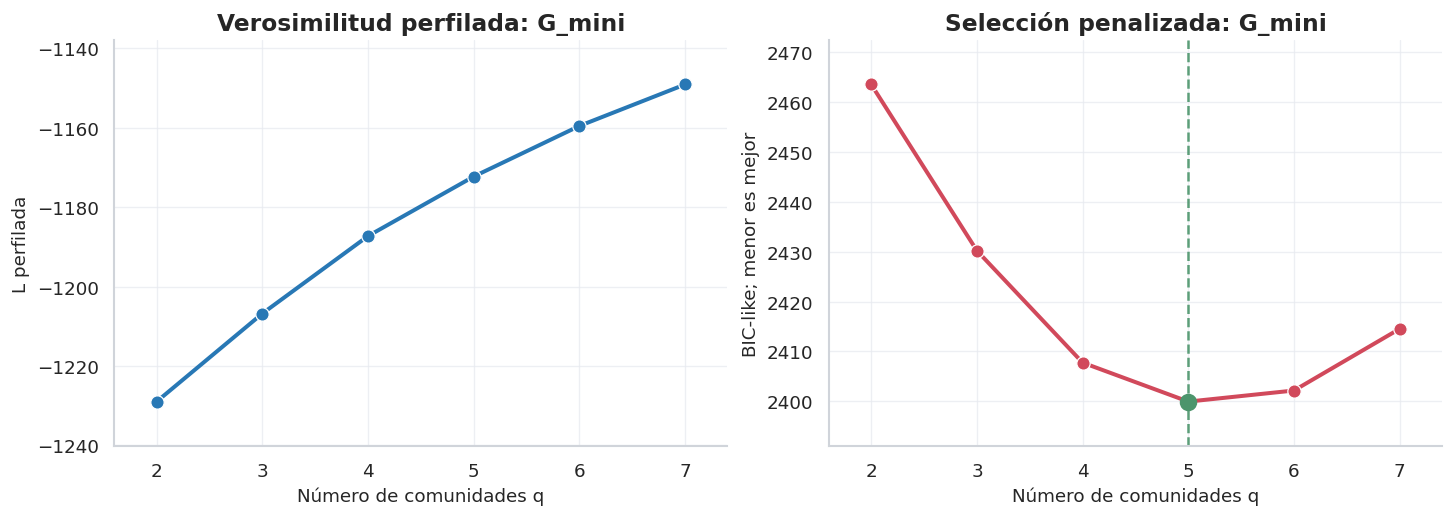

In [7]:
# ============================================================
# 7. Gráfica del barrido de q
# ============================================================
def plot_q_sweep(sweep: pd.DataFrame, graph_name: str) -> None:
    data = sweep[sweep["red"] == graph_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    sns.lineplot(data=data, x="q", y="L_perfilada", marker="o", markersize=8, linewidth=2.4, color="#2878B5", ax=axes[0])
    axes[0].set_title(f"Verosimilitud perfilada: {graph_name}")
    axes[0].set_xlabel("Número de comunidades q")
    axes[0].set_ylabel("L perfilada")
    axes[0].set_xticks(data["q"].tolist())

    sns.lineplot(data=data, x="q", y="BIC_like_menor_mejor", marker="o", markersize=8, linewidth=2.4, color="#D1495B", ax=axes[1])
    best_row = data.loc[data["BIC_like_menor_mejor"].idxmin()]
    axes[1].axvline(best_row["q"], color="#4C956C", linestyle="--", linewidth=1.5, alpha=0.9)
    axes[1].scatter(best_row["q"], best_row["BIC_like_menor_mejor"], s=90, color="#4C956C", zorder=4)
    axes[1].set_title(f"Selección penalizada: {graph_name}")
    axes[1].set_xlabel("Número de comunidades q")
    axes[1].set_ylabel("BIC-like; menor es mejor")
    axes[1].set_xticks(data["q"].tolist())

    for ax in axes:
        ax.grid(True, alpha=0.75)
        ax.margins(x=0.08, y=0.14)
    sns.despine(fig=fig)

    fig.savefig(OUT_DIR / f"barrido_q_{graph_name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()


plot_q_sweep(sweep_df, "G completa")
plot_q_sweep(sweep_df, "G_mini")

## 6. Resultados de comunidades

La tabla de nodos muestra la comunidad estimada, el grado y la componente conexa. Luego se reportan:

$$
M=(m_{rs}),
\qquad
\hat\Omega=(\hat\omega_{rs}).
$$

La matriz $M$ dice dónde están las aristas observadas. La matriz $\hat\Omega$ corrige por grado; por eso indica qué conexiones entre bloques son más intensas de lo esperable dadas las popularidades individuales de los personajes.

In [8]:
# ============================================================
# 8. Tablas de resultados
# ============================================================
def node_partition_table(Gx: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    components = {}
    for comp_id, comp in enumerate(nx.connected_components(Gx)):
        for node in comp:
            components[node] = comp_id
    rows = []
    for node in Gx.nodes():
        rows.append({
            "personaje": node,
            "comunidad": f"C{fit.labels[node]}",
            "grupo_notacion": fit.labels[node] + 1,
            "grado": Gx.degree(node),
            "componente_conexa": components[node],
        })
    return pd.DataFrame(rows).sort_values(["comunidad", "grado", "personaje"], ascending=[True, False, True]).reset_index(drop=True)


def community_summary_table(Gx: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    rows = []
    for c, nodes in fit.communities.items():
        sub = Gx.subgraph(nodes)
        boundary_edges = sum(
            1
            for u, v in Gx.edges()
            if (u in nodes and v not in nodes) or (v in nodes and u not in nodes)
        )
        rows.append({
            "comunidad": f"C{c}",
            "grupo_notacion": c + 1,
            "nodos": len(nodes),
            "aristas_internas": sub.number_of_edges(),
            "aristas_frontera": boundary_edges,
            "kappa_suma_grados": fit.kappa.iloc[c],
            "miembros": ", ".join(nodes),
        })
    return pd.DataFrame(rows)


for Gx, fit, stem in [(G, fit_full, "G"), (G_mini, fit_mini, "G_mini")]:
    print("\n" + "=" * 20, stem, "=" * 20)
    print(f"q seleccionado: {fit.q}")
    print(f"L perfilada: {fit.L:.6f}")
    print(f"BIC-like: {fit.bic_like:.6f}")
    print(f"Modularidad diagnóstica: {fit.modularity:.6f}")

    part = node_partition_table(Gx, fit)
    comm = community_summary_table(Gx, fit)

    display(Markdown(f"### Partición de nodos: {stem}"))
    display(part)
    display(Markdown(f"### Resumen por comunidad: {stem}"))
    display(comm)
    display(Markdown(f"### Matriz $M=(m_{{rs}})$: {stem}"))
    display(fit.M)
    display(Markdown(f"### Matriz $\\hat\\Omega$: {stem}"))
    display(fit.omega)

    part.to_csv(OUT_DIR / f"particion_nodos_{stem}.csv", index=False)
    comm.to_csv(OUT_DIR / f"resumen_comunidades_{stem}.csv", index=False)
    fit.M.to_csv(OUT_DIR / f"matriz_M_{stem}.csv")
    fit.omega.to_csv(OUT_DIR / f"omega_estimado_{stem}.csv")


==================== G ====================
q seleccionado: 6
L perfilada: -1305.318246
BIC-like: 2695.991884
Modularidad diagnóstica: 0.146013


### Partición de nodos: G

,personaje,comunidad,grupo_notacion,grado,componente_conexa
0,PADMÉ,C0,1,30,0
1,ELAN,C0,1,2,0
2,ZAM WESSEL,C0,1,2,0
3,DARTH SIDIOUS,C0,1,1,0
4,SHMI,C0,1,1,0
5,WATTO,C0,1,1,0
6,NUTE GUNRAY,C1,2,6,0
7,POGGLE,C1,2,6,0
8,SUN RIT,C1,2,6,0
9,BERU,C1,2,5,0


### Resumen por comunidad: G

,comunidad,grupo_notacion,nodos,aristas_internas,aristas_frontera,kappa_suma_grados,miembros
0,C0,1,6,0,37,70.0,"DARTH SIDIOUS, ELAN, PADMÉ, SHMI, WATTO, ZAM W..."
1,C1,2,13,12,31,73.0,"BERU, CLIEGG, JOBAL, NUTE GUNRAY, OWEN, POGGLE..."
2,C2,3,2,0,31,59.0,"DOOKU, OBI-WAN"
3,C3,4,2,1,31,69.0,"ANAKIN, COUNT DOOKU"
4,C4,5,9,8,11,35.0,"BOBA FETT, DEXTER JETTSTER, HERMIONE BAGWA, JA..."
5,C5,6,15,41,31,158.0,"AMIDALA, BAIL ORGANA, CAPTAIN TYPHO, CHILDREN,..."


...

,comunidad,grupo_notacion,nodos,aristas_internas,aristas_frontera,kappa_suma_grados,miembros
0,C0,1,2,1,47,107.0,"OBI-WAN, PADMÉ"
1,C1,2,13,12,33,75.0,"BERU, CLIEGG, DORME, JOBAL, NUTE GUNRAY, OWEN,..."
2,C2,3,4,6,5,22.0,"BOBA FETT, JANGO, JANGO FETT, TAUN WE"
3,C3,4,12,37,26,144.0,"AMIDALA, BAIL ORGANA, JAR JAR, KI-ADI-MUNDI, M..."
4,C4,5,3,2,29,70.0,"ANAKIN, CAPTAIN TYPHO, COUNT DOOKU"


### Matriz $M=(m_{rs})$: G_mini

,C0,C1,C2,C3,C4
C0,8.0,23.0,8.0,31.0,37.0
C1,23.0,34.0,0.0,0.0,18.0
C2,8.0,0.0,14.0,0.0,0.0
C3,31.0,0.0,0.0,102.0,11.0
C4,37.0,18.0,0.0,11.0,4.0


### Matriz $\hat\Omega$: G_mini

,C0,C1,C2,C3,C4
C0,0.292078,1.198006,1.420561,0.840992,2.064887
C1,1.198006,2.526578,0.000000,0.000000,1.433143
C2,1.420561,0.000000,12.090909,0.000000,0.000000
C3,0.840992,0.000000,0.000000,2.056134,0.456151
C4,2.064887,1.433143,0.000000,0.456151,0.341224


## 7. Visualización de particiones

Las figuras de red muestran la partición estimada por el DC-SBM. El tamaño de nodo crece con el grado, de modo que protagonistas o personajes puente aparecen visualmente más grandes.

Las figuras de $\hat\Omega$ ayudan a interpretar el tipo de estructura:

- diagonal alta: comunidad asortativa;
- fuera de diagonal alto: relación entre roles o subtramas complementarias.

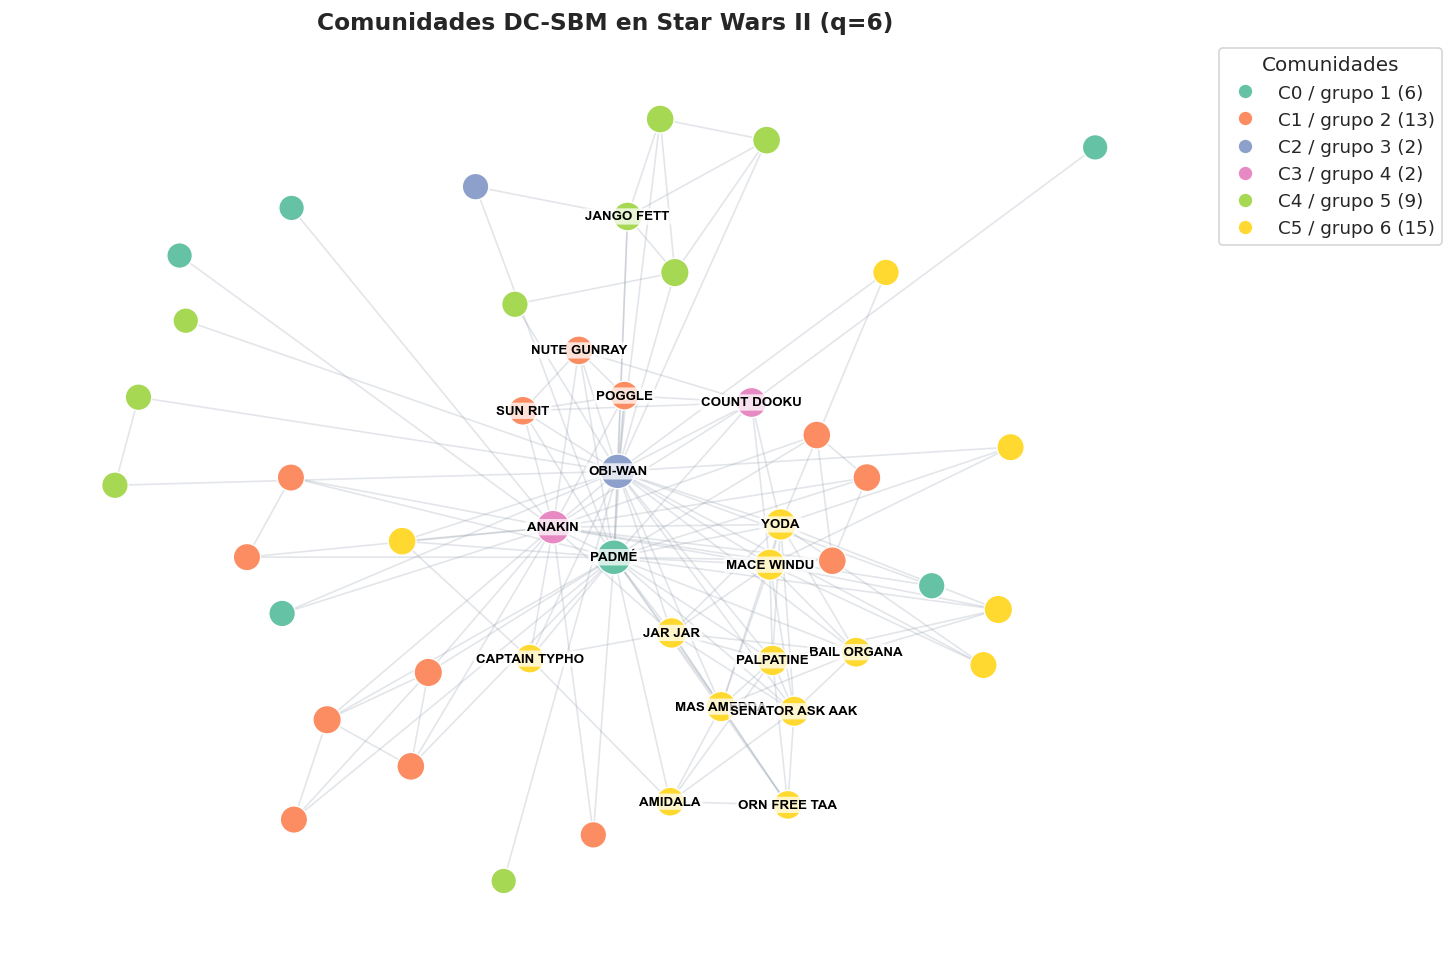

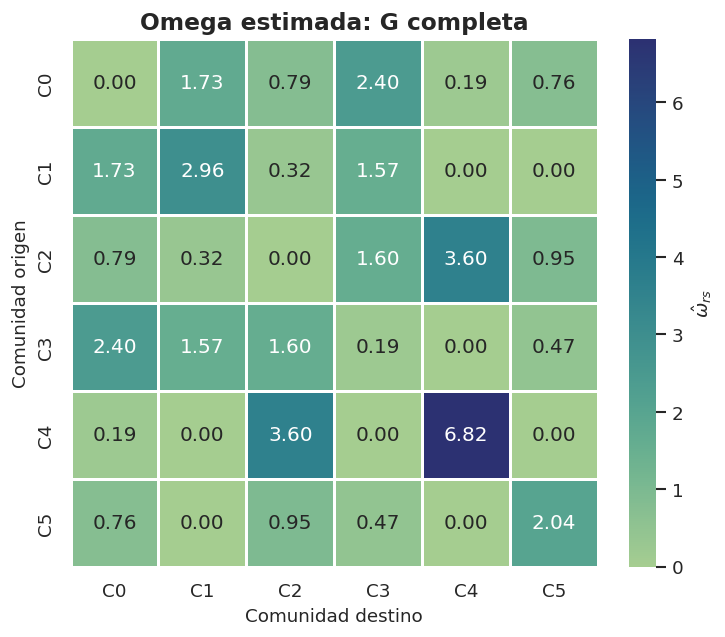

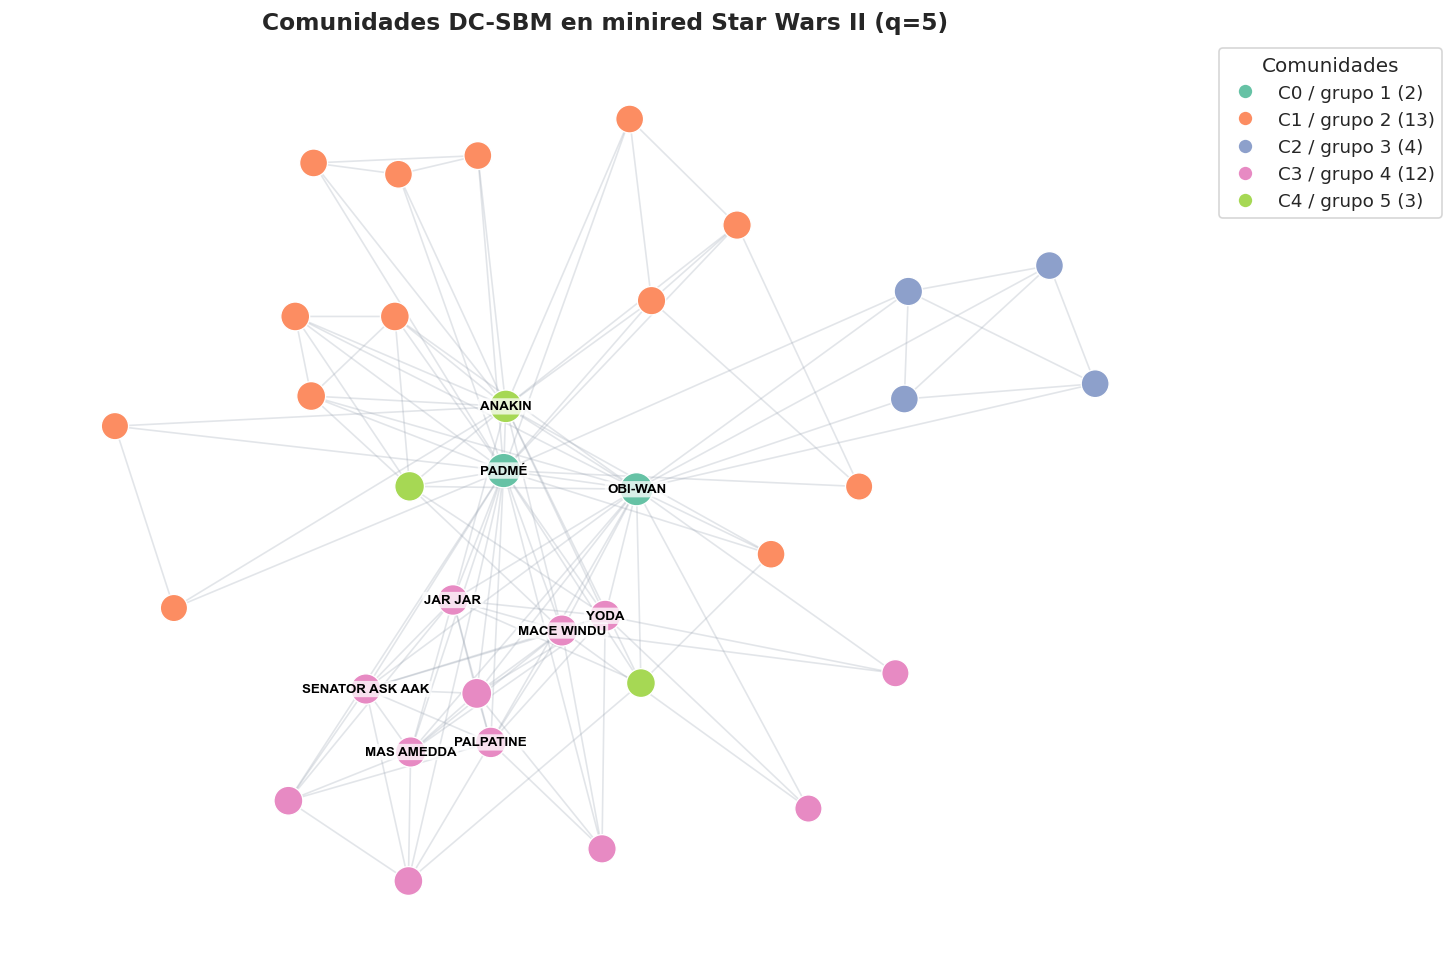

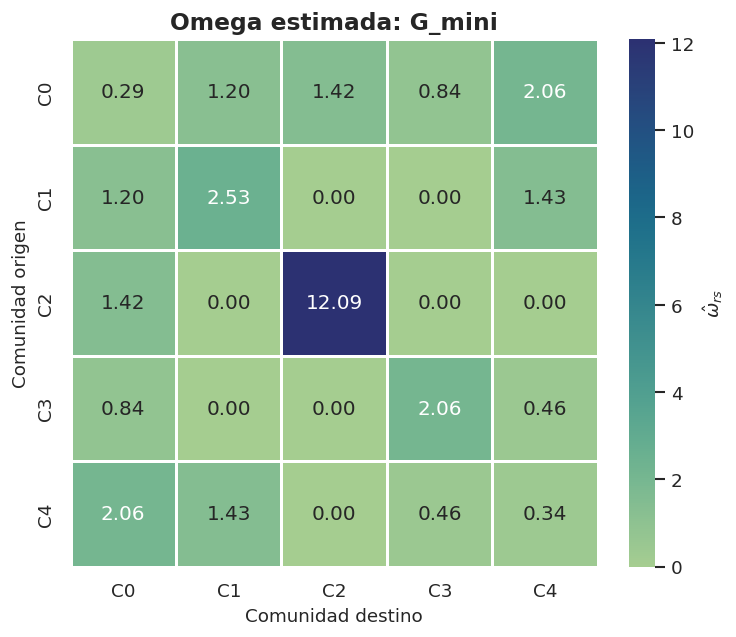

In [9]:
# ============================================================
# 9. Visualización de particiones y matrices omega
# ============================================================
def community_palette(q: int) -> list[tuple[float, float, float]]:
    if q <= 8:
        return sns.color_palette("Set2", n_colors=max(q, 3))[:q]
    return sns.color_palette("husl", n_colors=q)


def community_color_map(fit: DCSBMFit) -> dict[int, tuple[float, float, float]]:
    return {community: color for community, color in enumerate(community_palette(fit.q))}


def draw_partition(Gx: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    labels = fit.labels
    colors = community_color_map(fit)
    node_colors = [colors[labels[node]] for node in Gx.nodes()]
    node_sizes = [190 + 45 * np.sqrt(Gx.degree(node)) for node in Gx.nodes()]
    pos = nx.spring_layout(Gx, seed=RANDOM_SEED, k=0.55)

    fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
    ax.set_title(title)
    nx.draw_networkx_edges(Gx, pos, ax=ax, edge_color="#9AA4B2", alpha=0.28, width=1.0)
    nx.draw_networkx_nodes(Gx, pos, ax=ax, node_size=node_sizes, node_color=node_colors, edgecolors="white", linewidths=0.8)

    top_labels = {node: node for node, degree in Gx.degree() if degree >= max(3, np.percentile([d for _, d in Gx.degree()], 75))}
    nx.draw_networkx_labels(
        Gx,
        pos,
        labels=top_labels,
        ax=ax,
        font_size=8,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.16", "fc": "white", "ec": "none", "alpha": 0.75},
    )
    handles = [
        Line2D([0], [0], marker="o", color="w", label=f"C{c} / grupo {c+1} ({len(fit.communities[c])})",
               markerfacecolor=colors[c], markeredgecolor="white", markersize=9)
        for c in range(fit.q)
    ]
    ax.legend(handles=handles, title="Comunidades", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
    ax.axis("off")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_omega(fit: DCSBMFit, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(6.3, 5.2), constrained_layout=True)
    sns.heatmap(
        fit.omega,
        annot=True,
        fmt=".2f",
        cmap="crest",
        square=True,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": r"$\hat\omega_{rs}$"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Comunidad destino")
    ax.set_ylabel("Comunidad origen")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


draw_partition(G, fit_full, f"Comunidades DC-SBM en Star Wars II (q={fit_full.q})", "comunidades_G.png")
plot_omega(fit_full, "Omega estimada: G completa", "omega_G.png")

draw_partition(G_mini, fit_mini, f"Comunidades DC-SBM en minired Star Wars II (q={fit_mini.q})", "comunidades_G_mini.png")
plot_omega(fit_mini, "Omega estimada: G_mini", "omega_G_mini.png")

## 8. Visualizaciones diagnósticas

Las siguientes figuras están diseñadas para explicar el resultado, no solo para decorarlo:

- **Dashboard de comunidades:** compara tamaño, volumen de grado $\kappa_r$, aristas internas y aristas de frontera.
- **Radiografía de bloques:** junta $M$, $\hat\Omega$ y la proporción de masa que sale de cada bloque hacia los demás.
- **Adyacencia antes/después:** muestra cómo se revela la estructura cuando los nodos se ordenan por comunidad.
- **Vista focal del cruce dominante:** toma el par de bloques con mayor $\hat\omega_{rs}$ fuera de la diagonal para ver qué personajes explican esa conexión.

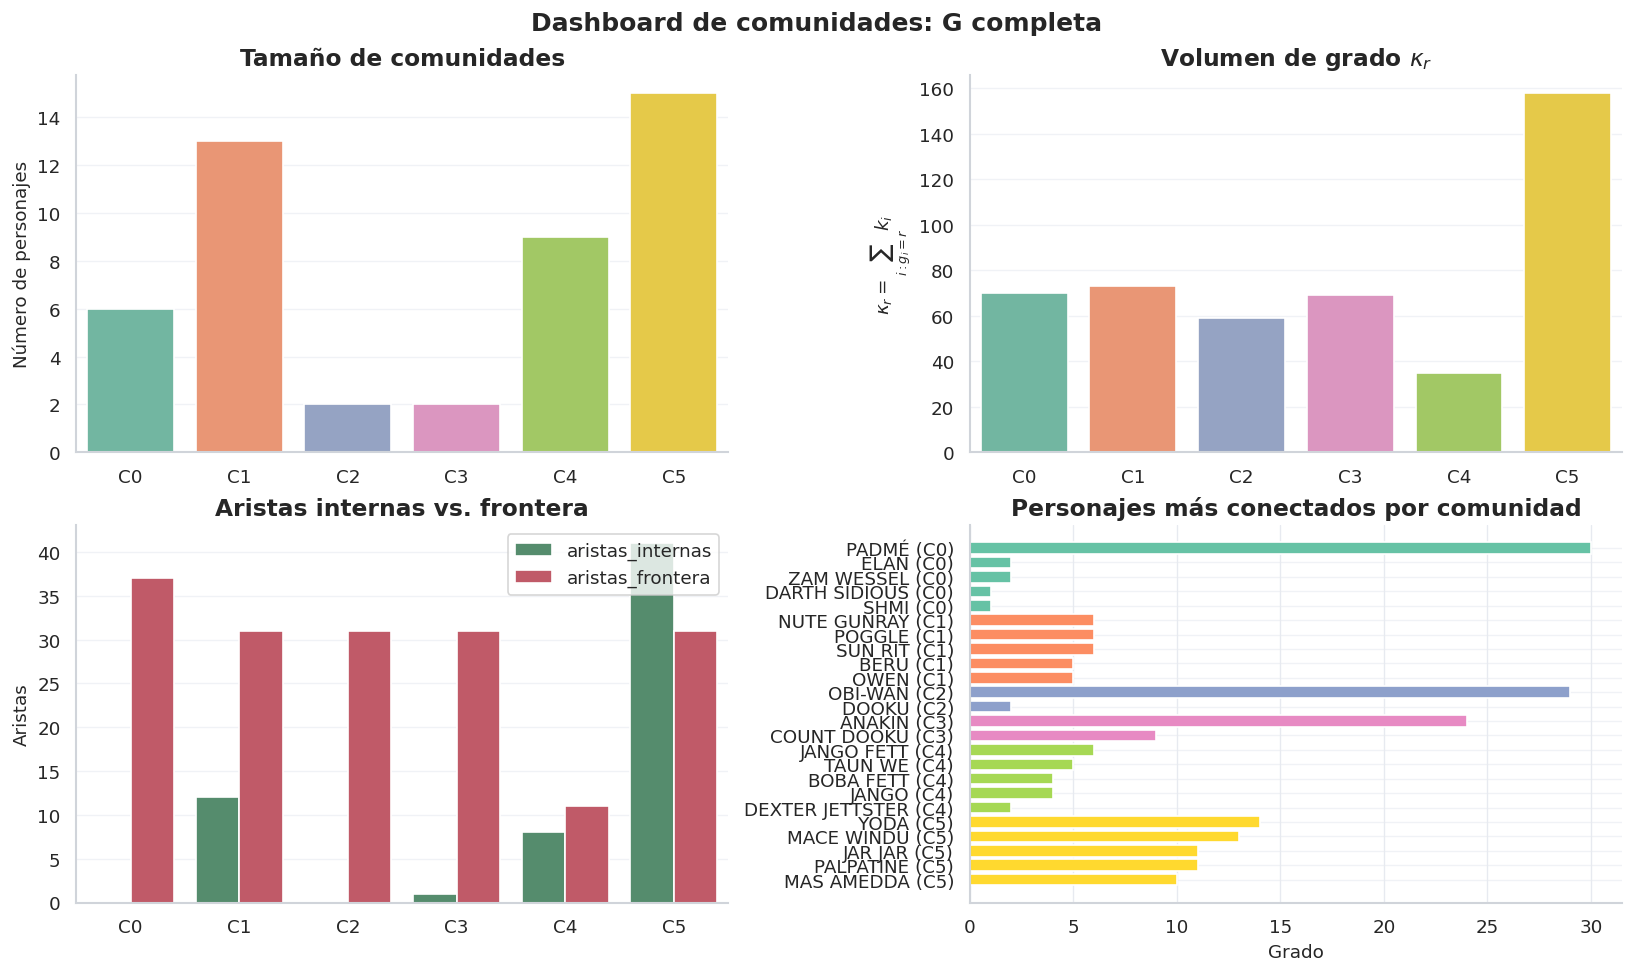

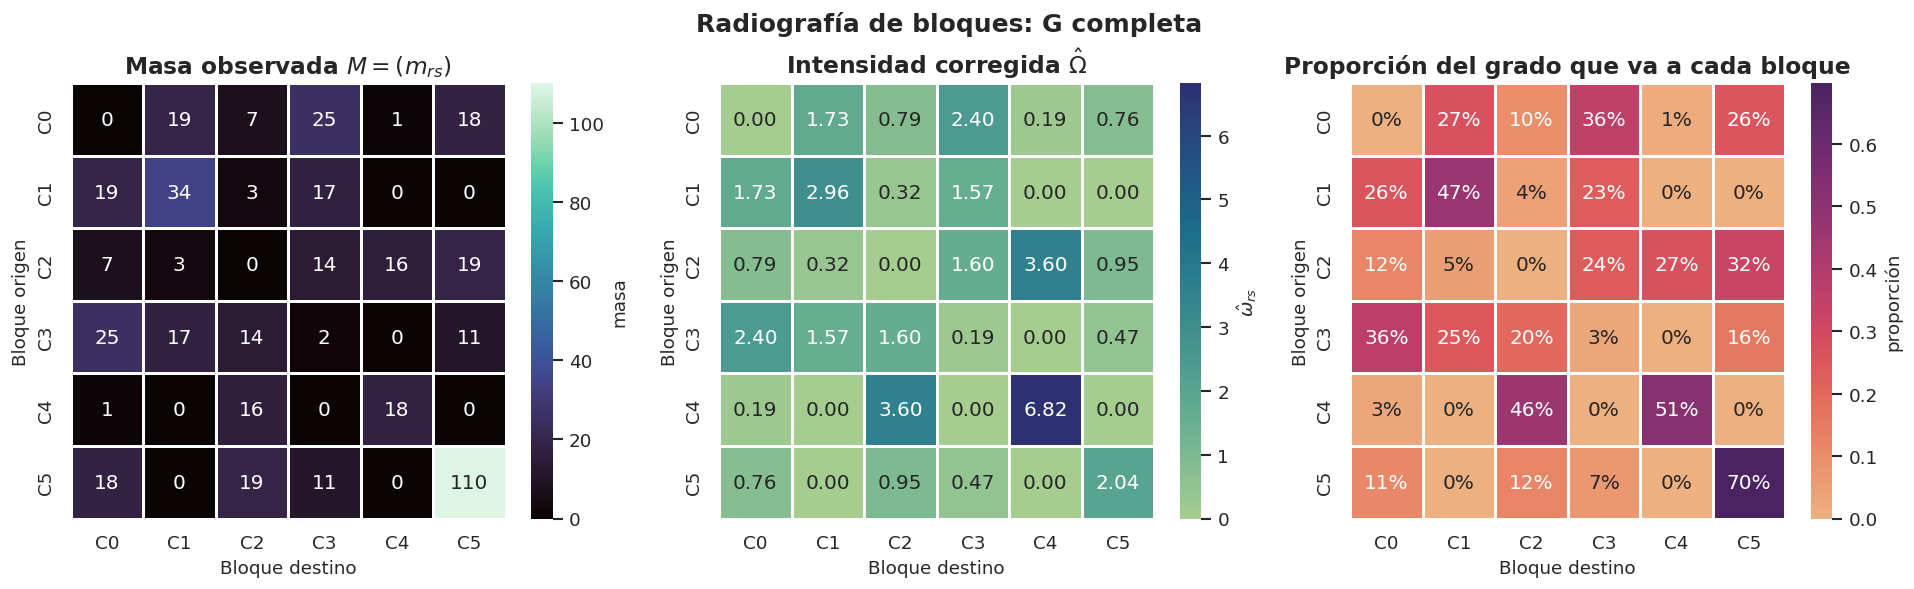

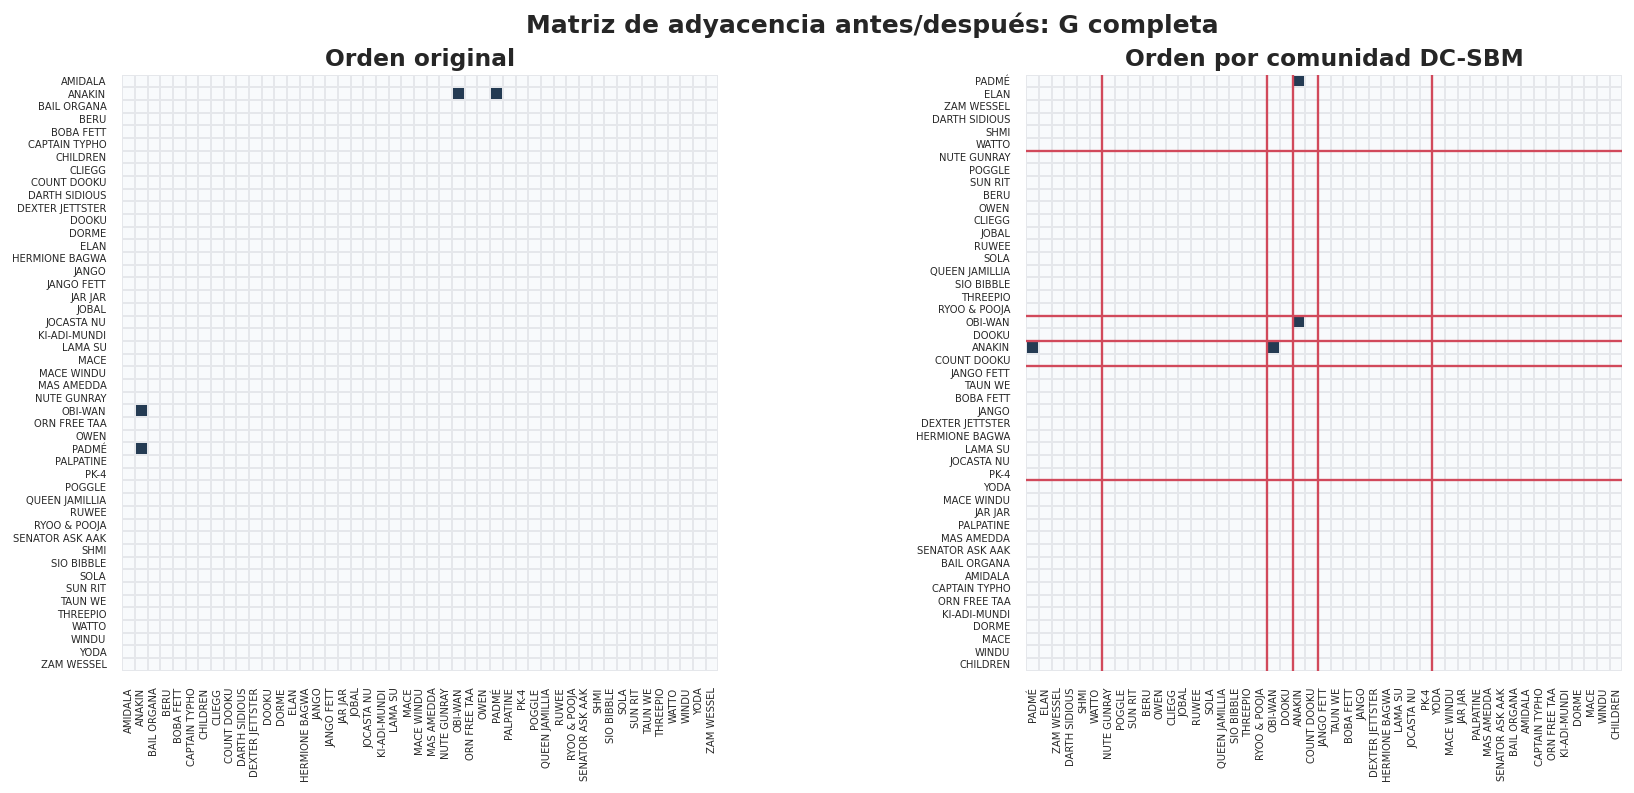

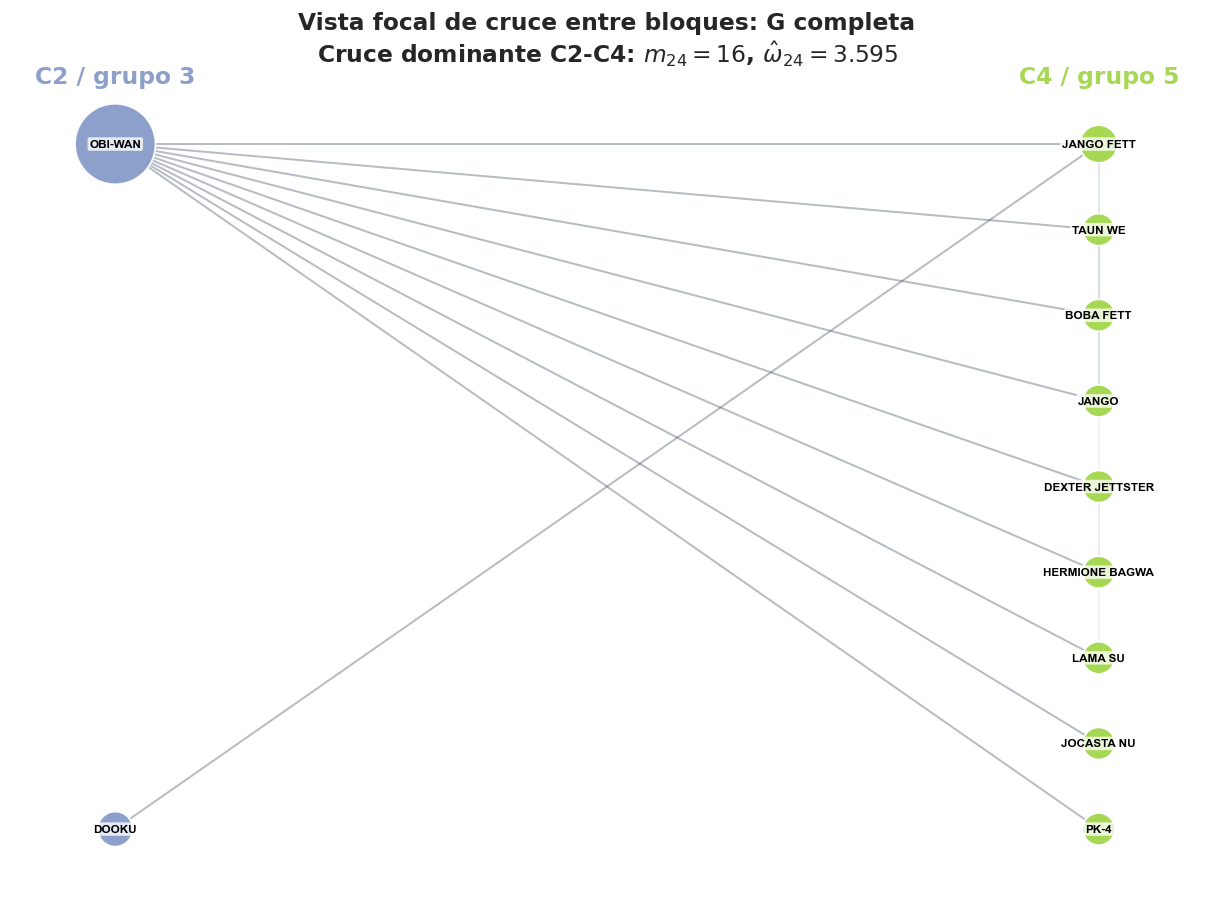

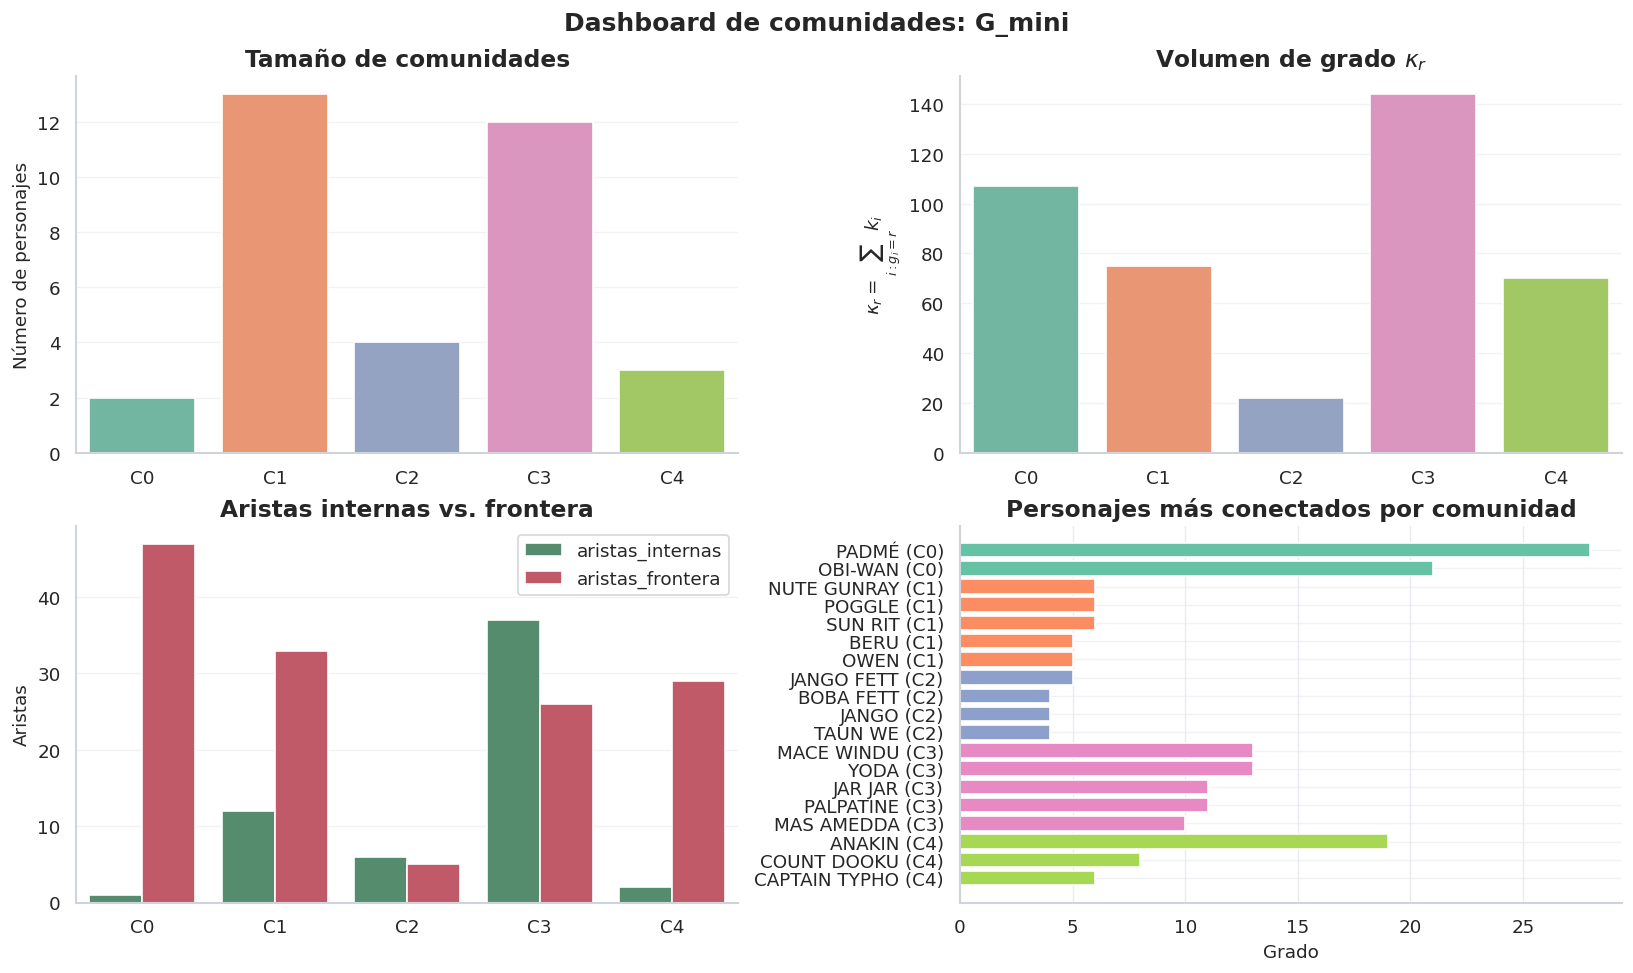

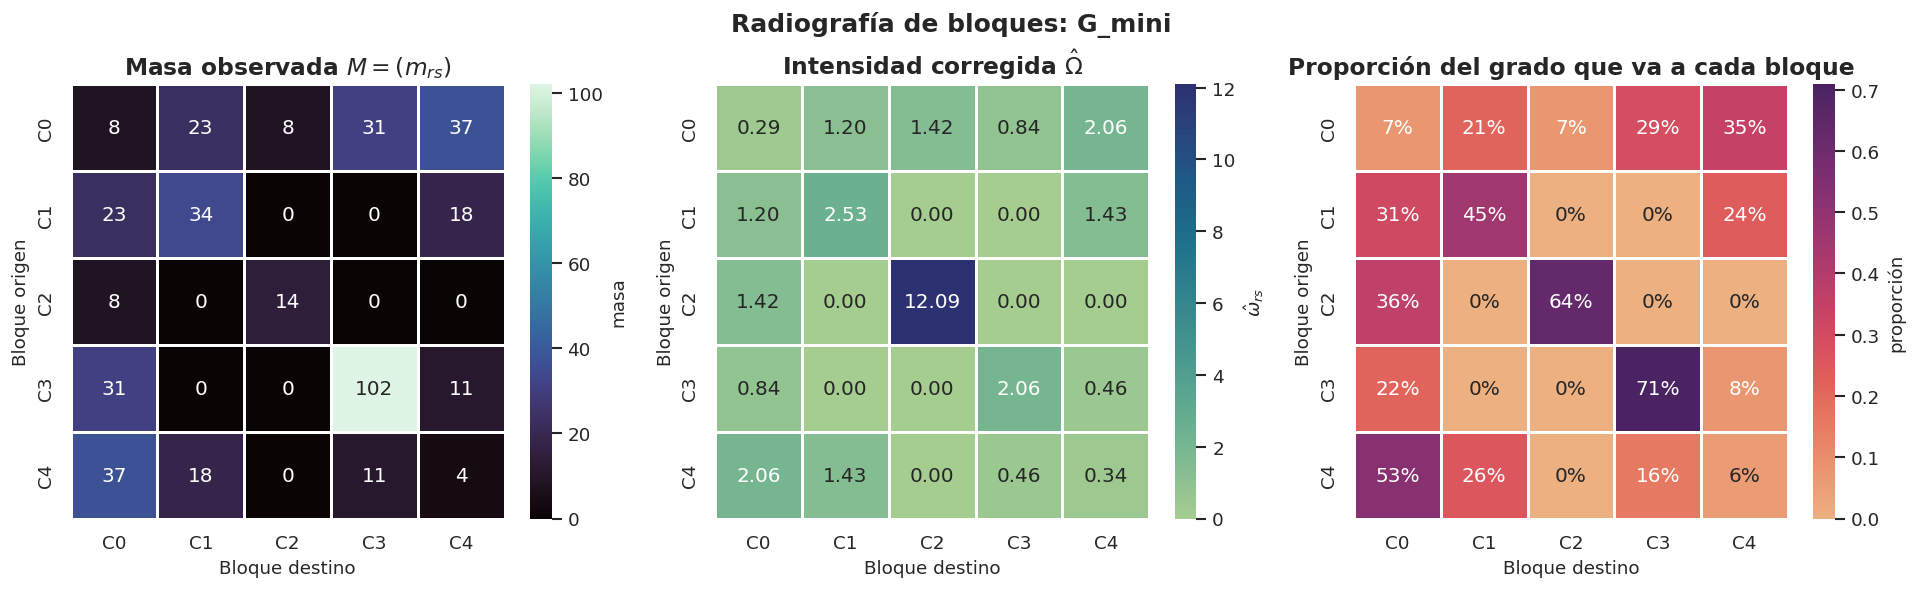

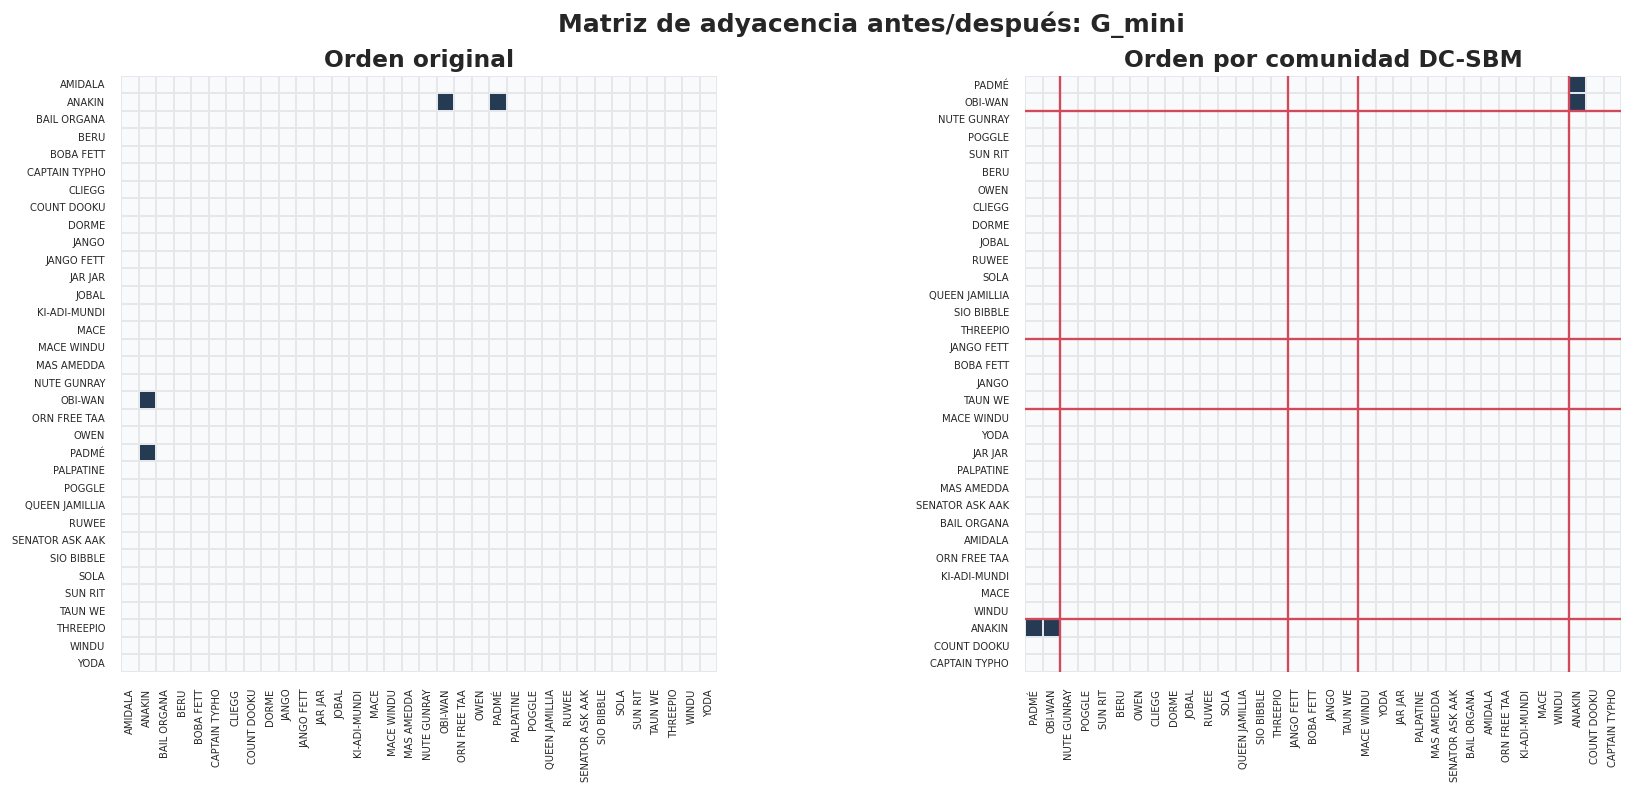

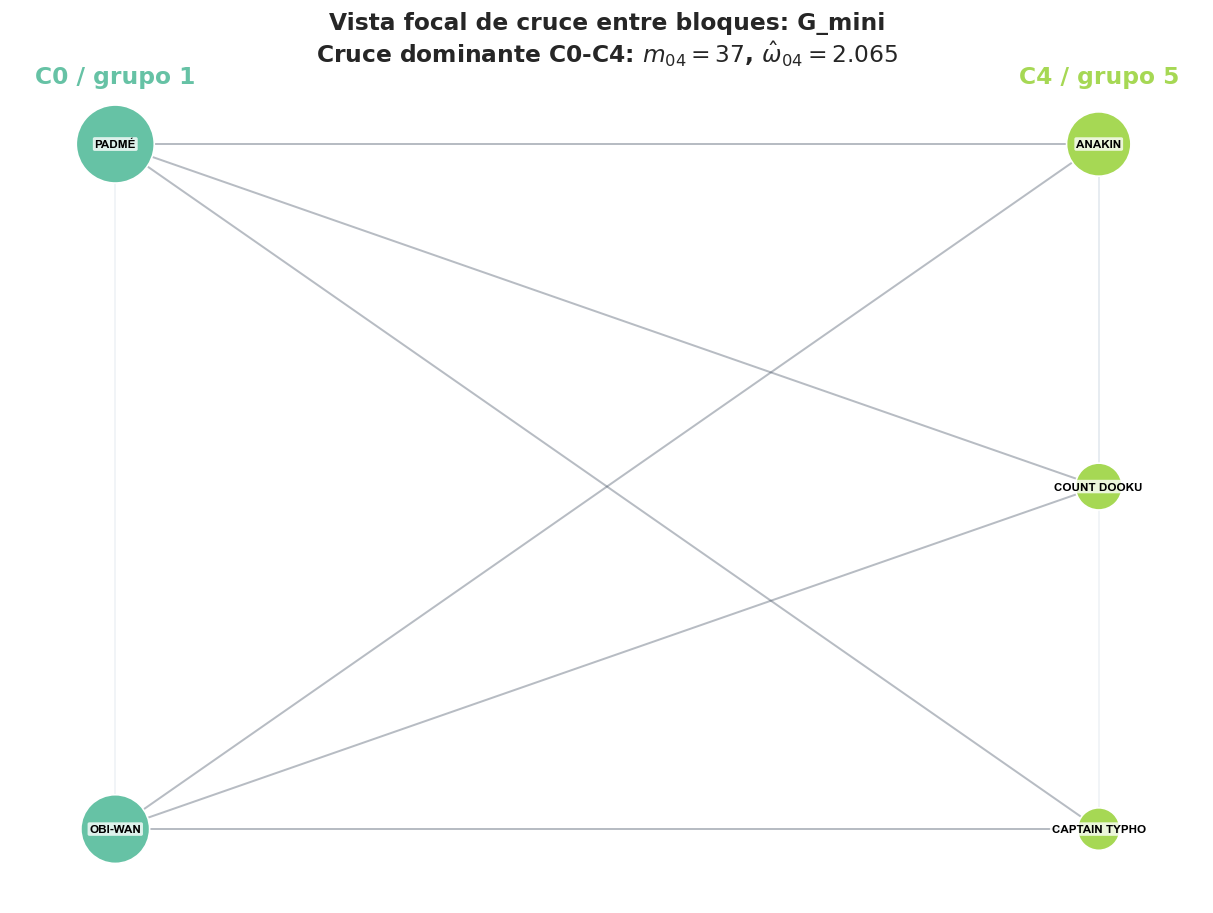

In [10]:
# ============================================================
# 10. Visualizaciones diagnósticas para intuición
# ============================================================
def safe_graph_name(name: str) -> str:
    return name.replace(" ", "_").replace("/", "_")


def ordered_nodes_for_plot(Gx: nx.Graph, fit: DCSBMFit) -> list[str]:
    ordered = []
    for c in range(fit.q):
        nodes = [node for node in fit.communities[c] if node in Gx]
        ordered.extend(sorted(nodes, key=lambda node: (-Gx.degree(node), node)))
    return ordered


def community_diagnostics(Gx: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    rows = []
    for c, nodes in fit.communities.items():
        node_set = set(nodes)
        internal_edges = Gx.subgraph(nodes).number_of_edges()
        boundary_edges = sum(
            1
            for u, v in Gx.edges()
            if (u in node_set and v not in node_set) or (v in node_set and u not in node_set)
        )
        rows.append({
            "comunidad": f"C{c}",
            "grupo": c + 1,
            "nodos": len(nodes),
            "aristas_internas": internal_edges,
            "aristas_frontera": boundary_edges,
            "kappa": float(fit.kappa.iloc[c]),
        })
    return pd.DataFrame(rows)


def plot_community_dashboard(Gx: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    diag = community_diagnostics(Gx, fit)
    colors = community_color_map(fit)
    palette = {f"C{c}": colors[c] for c in range(fit.q)}

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 8), constrained_layout=True)
    ax_size, ax_kappa, ax_edges, ax_nodes = axes.ravel()

    sns.barplot(data=diag, x="comunidad", y="nodos", hue="comunidad", palette=palette, legend=False, ax=ax_size)
    ax_size.set_title("Tamaño de comunidades")
    ax_size.set_xlabel("")
    ax_size.set_ylabel("Número de personajes")

    sns.barplot(data=diag, x="comunidad", y="kappa", hue="comunidad", palette=palette, legend=False, ax=ax_kappa)
    ax_kappa.set_title(r"Volumen de grado $\kappa_r$")
    ax_kappa.set_xlabel("")
    ax_kappa.set_ylabel(r"$\kappa_r=\sum_{i:g_i=r}k_i$")

    edge_long = diag.melt(id_vars=["comunidad"], value_vars=["aristas_internas", "aristas_frontera"], var_name="tipo", value_name="aristas")
    edge_palette = {"aristas_internas": "#4C956C", "aristas_frontera": "#D1495B"}
    sns.barplot(data=edge_long, x="comunidad", y="aristas", hue="tipo", palette=edge_palette, ax=ax_edges)
    ax_edges.set_title("Aristas internas vs. frontera")
    ax_edges.set_xlabel("")
    ax_edges.set_ylabel("Aristas")
    ax_edges.legend(title="", loc="upper right")

    top_rows = []
    for c, nodes in fit.communities.items():
        ranked = sorted([(node, Gx.degree(node)) for node in nodes], key=lambda x: (-x[1], x[0]))[:5]
        for node, degree in ranked:
            top_rows.append({"nodo": node, "grado": degree, "comunidad": f"C{c}", "id": c})
    top_df = pd.DataFrame(top_rows)
    top_df["etiqueta"] = top_df["nodo"] + " (" + top_df["comunidad"] + ")"
    top_df = top_df.sort_values(["id", "grado", "nodo"], ascending=[True, False, True])
    ax_nodes.barh(top_df["etiqueta"], top_df["grado"], color=[palette[c] for c in top_df["comunidad"]])
    ax_nodes.invert_yaxis()
    ax_nodes.set_title("Personajes más conectados por comunidad")
    ax_nodes.set_xlabel("Grado")
    ax_nodes.set_ylabel("")

    for ax in axes.ravel():
        ax.grid(True, axis="y", alpha=0.6)
    sns.despine(fig=fig)
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_block_radiography(fit: DCSBMFit, title: str, filename: str) -> None:
    M = fit.M.copy()
    omega = fit.omega.copy()
    row_share = M.div(M.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    specs = [
        (M, r"Masa observada $M=(m_{rs})$", ".0f", "mako", "masa"),
        (omega, r"Intensidad corregida $\hat\Omega$", ".2f", "crest", r"$\hat\omega_{rs}$"),
        (row_share, "Proporción del grado que va a cada bloque", ".0%", "flare", "proporción"),
    ]
    for ax, (mat, subtitle, fmt, cmap, cbar_label) in zip(axes, specs):
        sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, square=True, linewidths=0.8, linecolor="white", cbar_kws={"label": cbar_label}, ax=ax)
        ax.set_title(subtitle)
        ax.set_xlabel("Bloque destino")
        ax.set_ylabel("Bloque origen")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_adjacency_before_after(Gx: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    original_nodes = list(Gx.nodes())
    ordered_nodes = ordered_nodes_for_plot(Gx, fit)
    matrices = [
        (nx.to_numpy_array(Gx, nodelist=original_nodes, dtype=int), original_nodes, "Orden original"),
        (nx.to_numpy_array(Gx, nodelist=ordered_nodes, dtype=int), ordered_nodes, "Orden por comunidad DC-SBM"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
    cmap = sns.color_palette(["#F8FAFC", "#243B53"], as_cmap=True)
    for ax, (A, nodes, subtitle) in zip(axes, matrices):
        sns.heatmap(A, ax=ax, cmap=cmap, cbar=False, square=True, linewidths=0.08, linecolor="#E5E7EB", xticklabels=nodes, yticklabels=nodes)
        ax.set_title(subtitle)
        ax.tick_params(axis="x", labelrotation=90, labelsize=6)
        ax.tick_params(axis="y", labelsize=6)

    labels = [fit.labels[node] for node in ordered_nodes]
    boundaries = np.cumsum([sum(label == c for label in labels) for c in range(fit.q)])[:-1]
    for boundary in boundaries:
        axes[1].axhline(boundary, color="#D1495B", linewidth=1.4)
        axes[1].axvline(boundary, color="#D1495B", linewidth=1.4)

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def strongest_cross_pair(fit: DCSBMFit) -> tuple[int, int, float, float]:
    pairs = []
    for r in range(fit.q):
        for s in range(r + 1, fit.q):
            pairs.append((r, s, float(fit.omega.iloc[r, s]), float(fit.M.iloc[r, s])))
    pairs.sort(key=lambda item: (-item[2], -item[3], item[0], item[1]))
    return pairs[0]


def plot_dominant_cross_view(Gx: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    r, s, omega_rs, mass_rs = strongest_cross_pair(fit)
    nodes = [node for node in Gx.nodes() if fit.labels[node] in {r, s}]
    H = Gx.subgraph(nodes).copy()
    colors = community_color_map(fit)

    pos = {}
    for x, c in [(-1.8, r), (1.8, s)]:
        c_nodes = [node for node in fit.communities[c] if node in H]
        c_nodes = sorted(c_nodes, key=lambda node: (-sum(1 for nbr in Gx.neighbors(node) if fit.labels[nbr] != c), -Gx.degree(node), node))
        y_values = np.linspace(1.4, -1.4, len(c_nodes)) if len(c_nodes) > 1 else np.array([0.0])
        for node, y in zip(c_nodes, y_values):
            pos[node] = (x, float(y))

    node_colors = [colors[fit.labels[node]] for node in H.nodes()]
    cross_degree = {node: sum(1 for nbr in Gx.neighbors(node) if fit.labels[nbr] != fit.labels[node]) for node in H.nodes()}
    node_sizes = [300 + 70 * cross_degree[node] for node in H.nodes()]
    cross_edges = [(u, v) for u, v in H.edges() if fit.labels[u] != fit.labels[v]]
    internal_edges = [(u, v) for u, v in H.edges() if fit.labels[u] == fit.labels[v]]

    fig, ax = plt.subplots(figsize=(10, 7.5), constrained_layout=True)
    nx.draw_networkx_edges(H, pos, edgelist=internal_edges, ax=ax, edge_color="#CBD5E1", alpha=0.28, width=1.1)
    nx.draw_networkx_edges(H, pos, edgelist=cross_edges, ax=ax, edge_color="#334155", alpha=0.35, width=1.2)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors, node_size=node_sizes, edgecolors="white", linewidths=1.0)
    nx.draw_networkx_labels(
        H,
        pos,
        ax=ax,
        font_size=7,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.78},
    )
    ax.text(-1.8, 1.65, f"C{r} / grupo {r+1}", color=colors[r], fontsize=14, fontweight="bold", ha="center")
    ax.text(1.8, 1.65, f"C{s} / grupo {s+1}", color=colors[s], fontsize=14, fontweight="bold", ha="center")
    ax.set_title(
        f"{title}\nCruce dominante C{r}-C{s}: "
        + rf"$m_{{{r}{s}}}={mass_rs:.0f}$, $\hat\omega_{{{r}{s}}}={omega_rs:.3f}$"
    )
    ax.axis("off")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


for Gx, fit in [(G, fit_full), (G_mini, fit_mini)]:
    safe = safe_graph_name(fit.graph_name)
    plot_community_dashboard(Gx, fit, f"Dashboard de comunidades: {fit.graph_name}", f"dashboard_comunidades_{safe}.png")
    plot_block_radiography(fit, f"Radiografía de bloques: {fit.graph_name}", f"radiografia_bloques_{safe}.png")
    plot_adjacency_before_after(Gx, fit, f"Matriz de adyacencia antes/después: {fit.graph_name}", f"adyacencia_antes_despues_{safe}.png")
    plot_dominant_cross_view(Gx, fit, f"Vista focal de cruce entre bloques: {fit.graph_name}", f"vista_cruce_dominante_{safe}.png")

## 9. Interpretación específica

La interpretación se basa en tres preguntas:

1. ¿Qué $q$ selecciona el criterio penalizado?
2. ¿Las entradas dominantes de $\hat\Omega$ están en la diagonal o fuera de ella?
3. ¿Qué personajes explican cada bloque y qué subtrama representan?

En una red narrativa, una comunidad puede representar una subtrama densa, pero también puede representar un rol: por ejemplo, personajes que conectan el Senado con los Jedi, o personajes que unen la trama de Kamino/Geonosis con la trama principal.

In [11]:
# ============================================================
# 11. Interpretación automática y específica
# ============================================================
def dominant_block_pairs(fit: DCSBMFit, top_n: int = 5) -> list[tuple[str, str, float, float]]:
    pairs = []
    for i, row in enumerate(fit.omega.index):
        for j, col in enumerate(fit.omega.columns):
            if i <= j:
                pairs.append((row, col, float(fit.omega.iloc[i, j]), float(fit.M.iloc[i, j])))
    pairs.sort(key=lambda item: (-item[2], -item[3], item[0], item[1]))
    return pairs[:top_n]


def bridge_nodes_between_blocks(Gx: nx.Graph, fit: DCSBMFit, r: int, s: int, top_n: int = 8) -> list[str]:
    scores = []
    for node in Gx.nodes():
        label = fit.labels[node]
        if label not in {r, s}:
            continue
        cross_degree = sum(1 for nbr in Gx.neighbors(node) if fit.labels[nbr] != label)
        if cross_degree:
            scores.append((node, cross_degree, Gx.degree(node)))
    scores.sort(key=lambda x: (-x[1], -x[2], x[0]))
    return [f"{node}({cross}; grado {degree})" for node, cross, degree in scores[:top_n]]


def narrative_hint(nodes: list[str]) -> str:
    node_set = set(nodes)
    hints = []
    if {"ANAKIN", "PADME", "AMIDALA"} & node_set:
        hints.append("trama Anakin-Padmé/Naboo")
    if {"OBI-WAN", "JANGO FETT", "BOBA FETT", "COUNT DOOKU"} & node_set:
        hints.append("investigación, Kamino/Geonosis y conflicto separatista")
    if {"YODA", "MACE WINDU", "PALPATINE", "BAIL ORGANA"} & node_set:
        hints.append("Jedi/Senado/República")
    if {"OWEN", "BERU", "CLIEGG", "SHMI"} & node_set:
        hints.append("Tatooine/familia Lars")
    if not hints:
        return "lectura narrativa: bloque periférico o de soporte escénico"
    return "lectura narrativa: " + "; ".join(hints)


def interpret_fit(Gx: nx.Graph, fit: DCSBMFit) -> str:
    omega = fit.omega.values
    diag = np.diag(omega)
    off = omega[~np.eye(fit.q, dtype=bool)]
    mean_diag = float(np.mean(diag)) if len(diag) else np.nan
    mean_off = float(np.mean(off)) if len(off) else np.nan
    ratio = mean_diag / mean_off if mean_off > 0 else np.inf

    lines = []
    lines.append(f"### Interpretación específica: {fit.graph_name}")
    lines.append(f"- El criterio penalizado seleccionó $q={fit.q}$ con $L={fit.L:.4f}$ y BIC-like={fit.bic_like:.4f}.")
    lines.append(f"- Modularidad diagnóstica: $Q={fit.modularity:.4f}$. Si es baja o moderada, eso sugiere que el SBM está capturando roles además de grupos densos.")
    lines.append(f"- Media diagonal de $\\hat\\Omega$: {mean_diag:.3f}; media fuera de diagonal: {mean_off:.3f}; razón diagonal/fuera={ratio:.3f}.")

    formatted_pairs = ", ".join(f"{a}-{b}: omega={omega_val:.3f}, M={mass:.0f}" for a, b, omega_val, mass in dominant_block_pairs(fit, top_n=min(5, fit.q * (fit.q + 1) // 2)))
    lines.append(f"- Pares de bloques más intensos después de corregir por grado: {formatted_pairs}.")

    for c, nodes in fit.communities.items():
        sub = Gx.subgraph(nodes)
        top_degrees = sorted([(node, Gx.degree(node)) for node in nodes], key=lambda x: (-x[1], x[0]))[:6]
        lines.append(
            f"- C{c} / grupo {c+1}: {len(nodes)} personajes; {sub.number_of_edges()} aristas internas; "
            f"$\\kappa_{c+1}={fit.kappa.iloc[c]:.0f}$. "
            f"Principales por grado: " + ", ".join(f"{node}({deg})" for node, deg in top_degrees) + ". "
            + narrative_hint(nodes)
            + "."
        )
        lines.append(f"  Miembros: {', '.join(nodes)}.")

    off_pairs = []
    for r in range(fit.q):
        for s in range(r + 1, fit.q):
            off_pairs.append((r, s, float(fit.omega.iloc[r, s]), float(fit.M.iloc[r, s])))
    off_pairs.sort(key=lambda item: (-item[2], -item[3]))
    if off_pairs and off_pairs[0][2] > 0:
        r, s, omega_rs, mass_rs = off_pairs[0]
        bridges = bridge_nodes_between_blocks(Gx, fit, r, s)
        lines.append(
            f"- El vínculo entre bloques más relevante es C{r}-C{s} "
            f"(grupos {r+1}-{s+1}): $m_{{{r+1}{s+1}}}={mass_rs:.0f}$ y "
            f"$\\hat\\omega_{{{r+1}{s+1}}}={omega_rs:.3f}$. "
            f"Personajes que más explican ese cruce: {', '.join(bridges)}."
        )
    return "\n".join(lines)


for Gx, fit in [(G, fit_full), (G_mini, fit_mini)]:
    text = interpret_fit(Gx, fit)
    display(Markdown(text))
    with open(OUT_DIR / f"interpretacion_{fit.graph_name.replace(' ', '_')}.md", "w", encoding="utf-8") as f:
        f.write(text)

### Interpretación específica: G completa
- El criterio penalizado seleccionó $q=6$ con $L=-1305.3182$ y BIC-like=2695.9919.
- Modularidad diagnóstica: $Q=0.1460$. Si es baja o moderada, eso sugiere que el SBM está capturando roles además de grupos densos.
- Media diagonal de $\hat\Omega$: 2.003; media fuera de diagonal: 0.957; razón diagonal/fuera=2.093.
- Pares de bloques más intensos después de corregir por grado: C4-C4: omega=6.818, M=18, C2-C4: omega=3.595, M=16, C1-C1: omega=2.960, M=34, C0-C3: omega=2.402, M=25, C5-C5: omega=2.045, M=110.
- C0 / grupo 1: 6 personajes; 0 aristas internas; $\kappa_1=70$. Principales por grado: PADMÉ(30), ELAN(2), ZAM WESSEL(2), DARTH SIDIOUS(1), SHMI(1), WATTO(1). lectura narrativa: Tatooine/familia Lars.
  Miembros: DARTH SIDIOUS, ELAN, PADMÉ, SHMI, WATTO, ZAM WESSEL.
- C1 / grupo 2: 13 personajes; 12 aristas internas; $\kappa_2=73$. Principales por grado: NUTE GUNRAY(6), POGGLE(6), SUN RIT(6), BERU(5), OWEN(5), CLIEGG(4). lectura narrativa: Tatooine/familia Lars.
  Miembros: BERU, CLIEGG, JOBAL, NUTE GUNRAY, OWEN, POGGLE, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SIO BIBBLE, SOLA, SUN RIT, THREEPIO.
- C2 / grupo 3: 2 personajes; 0 aristas internas; $\kappa_3=59$. Principales por grado: OBI-WAN(29), DOOKU(2). lectura narrativa: investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: DOOKU, OBI-WAN.
- C3 / grupo 4: 2 personajes; 1 aristas internas; $\kappa_4=69$. Principales por grado: ANAKIN(24), COUNT DOOKU(9). lectura narrativa: trama Anakin-Padmé/Naboo; investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: ANAKIN, COUNT DOOKU.
- C4 / grupo 5: 9 personajes; 8 aristas internas; $\kappa_5=35$. Principales por grado: JANGO FETT(6), TAUN WE(5), BOBA FETT(4), JANGO(4), DEXTER JETTSTER(2), HERMIONE BAGWA(2). lectura narrativa: investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: BOBA FETT, DEXTER JETTSTER, HERMIONE BAGWA, JANGO, JANGO FETT, JOCASTA NU, LAMA SU, PK-4, TAUN WE.
- C5 / grupo 6: 15 personajes; 41 aristas internas; $\kappa_6=158$. Principales por grado: YODA(14), MACE WINDU(13), JAR JAR(11), PALPATINE(11), MAS AMEDDA(10), SENATOR ASK AAK(10). lectura narrativa: trama Anakin-Padmé/Naboo; Jedi/Senado/República.
  Miembros: AMIDALA, BAIL ORGANA, CAPTAIN TYPHO, CHILDREN, DORME, JAR JAR, KI-ADI-MUNDI, MACE, MACE WINDU, MAS AMEDDA, ORN FREE TAA, PALPATINE, SENATOR ASK AAK, WINDU, YODA.
- El vínculo entre bloques más relevante es C2-C4 (grupos 3-5): $m_{35}=16$ y $\hat\omega_{35}=3.595$. Personajes que más explican ese cruce: OBI-WAN(29; grado 29), JANGO FETT(3; grado 6), DOOKU(2; grado 2), TAUN WE(1; grado 5), BOBA FETT(1; grado 4), JANGO(1; grado 4), DEXTER JETTSTER(1; grado 2), HERMIONE BAGWA(1; grado 2).

### Interpretación específica: G_mini
- El criterio penalizado seleccionó $q=5$ con $L=-1172.2565$ y BIC-like=2399.9648.
- Modularidad diagnóstica: $Q=0.1403$. Si es baja o moderada, eso sugiere que el SBM está capturando roles además de grupos densos.
- Media diagonal de $\hat\Omega$: 3.461; media fuera de diagonal: 0.741; razón diagonal/fuera=4.669.
- Pares de bloques más intensos después de corregir por grado: C2-C2: omega=12.091, M=14, C1-C1: omega=2.527, M=34, C0-C4: omega=2.065, M=37, C3-C3: omega=2.056, M=102, C1-C4: omega=1.433, M=18.
- C0 / grupo 1: 2 personajes; 1 aristas internas; $\kappa_1=107$. Principales por grado: PADMÉ(28), OBI-WAN(21). lectura narrativa: investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: OBI-WAN, PADMÉ.
- C1 / grupo 2: 13 personajes; 12 aristas internas; $\kappa_2=75$. Principales por grado: NUTE GUNRAY(6), POGGLE(6), SUN RIT(6), BERU(5), OWEN(5), CLIEGG(4). lectura narrativa: Tatooine/familia Lars.
  Miembros: BERU, CLIEGG, DORME, JOBAL, NUTE GUNRAY, OWEN, POGGLE, QUEEN JAMILLIA, RUWEE, SIO BIBBLE, SOLA, SUN RIT, THREEPIO.
- C2 / grupo 3: 4 personajes; 6 aristas internas; $\kappa_3=22$. Principales por grado: JANGO FETT(5), BOBA FETT(4), JANGO(4), TAUN WE(4). lectura narrativa: investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: BOBA FETT, JANGO, JANGO FETT, TAUN WE.
- C3 / grupo 4: 12 personajes; 37 aristas internas; $\kappa_4=144$. Principales por grado: MACE WINDU(13), YODA(13), JAR JAR(11), PALPATINE(11), MAS AMEDDA(10), SENATOR ASK AAK(10). lectura narrativa: trama Anakin-Padmé/Naboo; Jedi/Senado/República.
  Miembros: AMIDALA, BAIL ORGANA, JAR JAR, KI-ADI-MUNDI, MACE, MACE WINDU, MAS AMEDDA, ORN FREE TAA, PALPATINE, SENATOR ASK AAK, WINDU, YODA.
- C4 / grupo 5: 3 personajes; 2 aristas internas; $\kappa_5=70$. Principales por grado: ANAKIN(19), COUNT DOOKU(8), CAPTAIN TYPHO(6). lectura narrativa: trama Anakin-Padmé/Naboo; investigación, Kamino/Geonosis y conflicto separatista.
  Miembros: ANAKIN, CAPTAIN TYPHO, COUNT DOOKU.
- El vínculo entre bloques más relevante es C0-C4 (grupos 1-5): $m_{15}=37$ y $\hat\omega_{15}=2.065$. Personajes que más explican ese cruce: PADMÉ(27; grado 28), OBI-WAN(20; grado 21), ANAKIN(17; grado 19), COUNT DOOKU(7; grado 8), CAPTAIN TYPHO(5; grado 6).

## 10. Visualización final: matriz de adyacencia y red partida

Para cerrar, ordenamos la matriz de adyacencia por comunidad y dibujamos la red en columnas. Esta figura resume el caso:

- la matriz ordenada muestra bloques diagonales si hay subtramas densas;
- los rectángulos fuera de la diagonal muestran interacción entre subtramas o roles;
- la red partida permite identificar qué personajes actúan como puentes entre bloques.

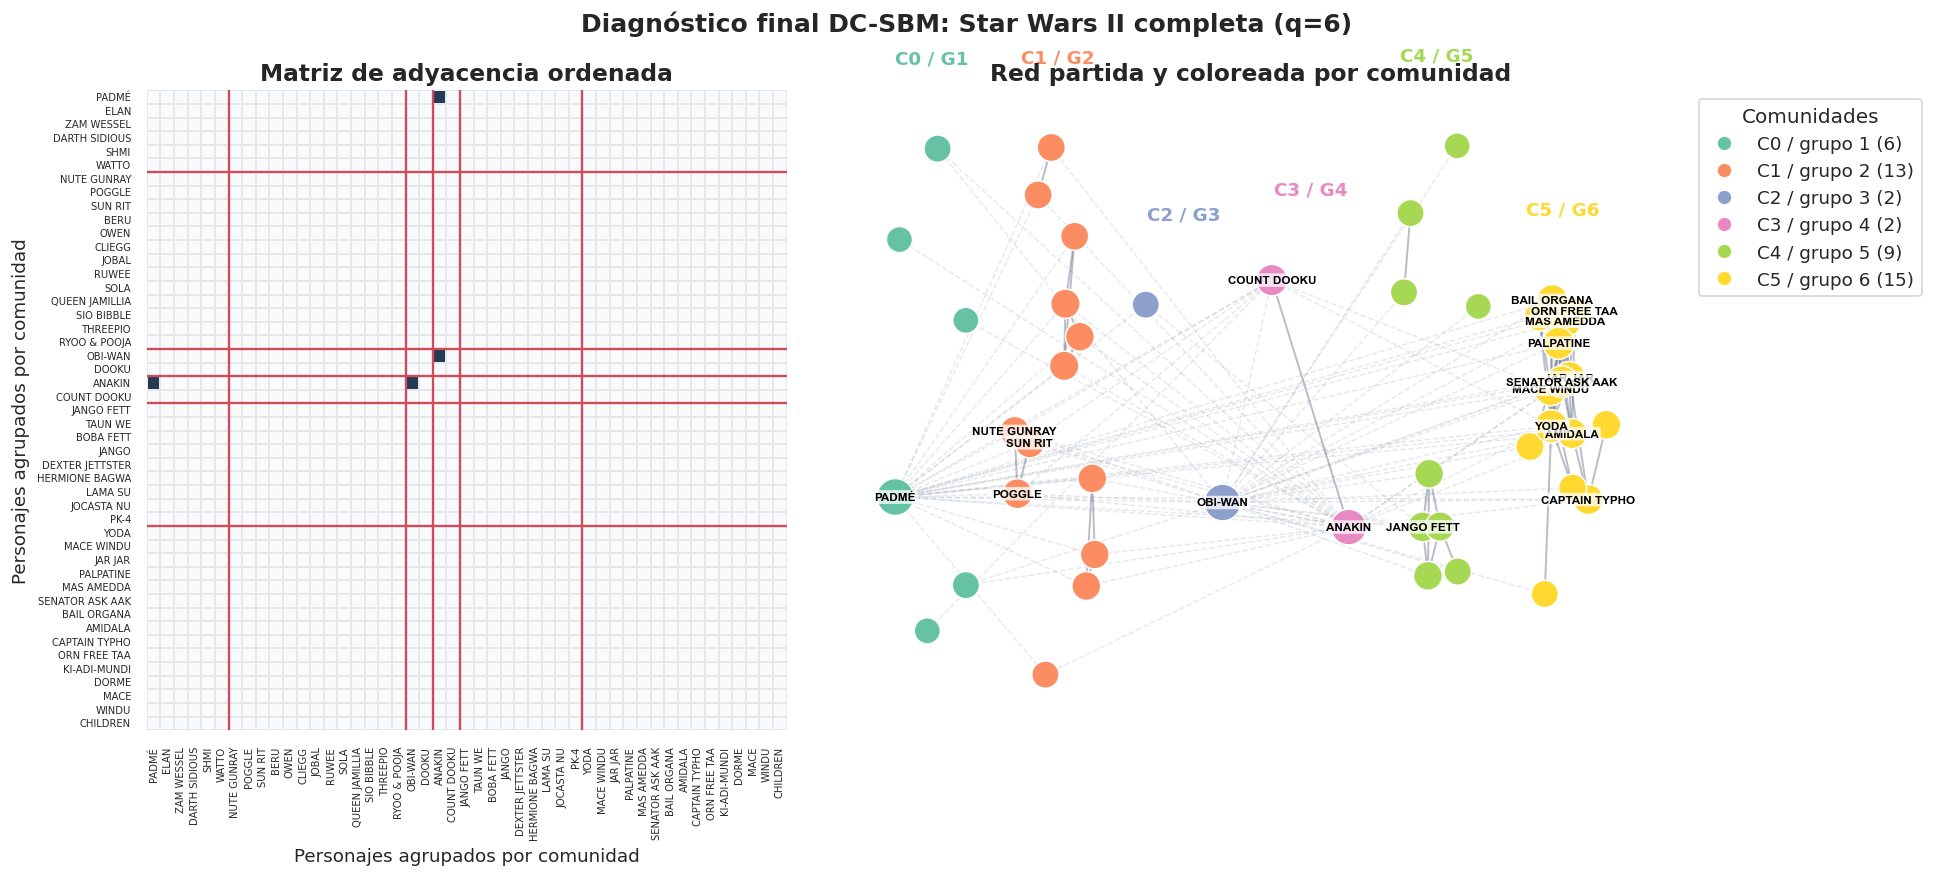

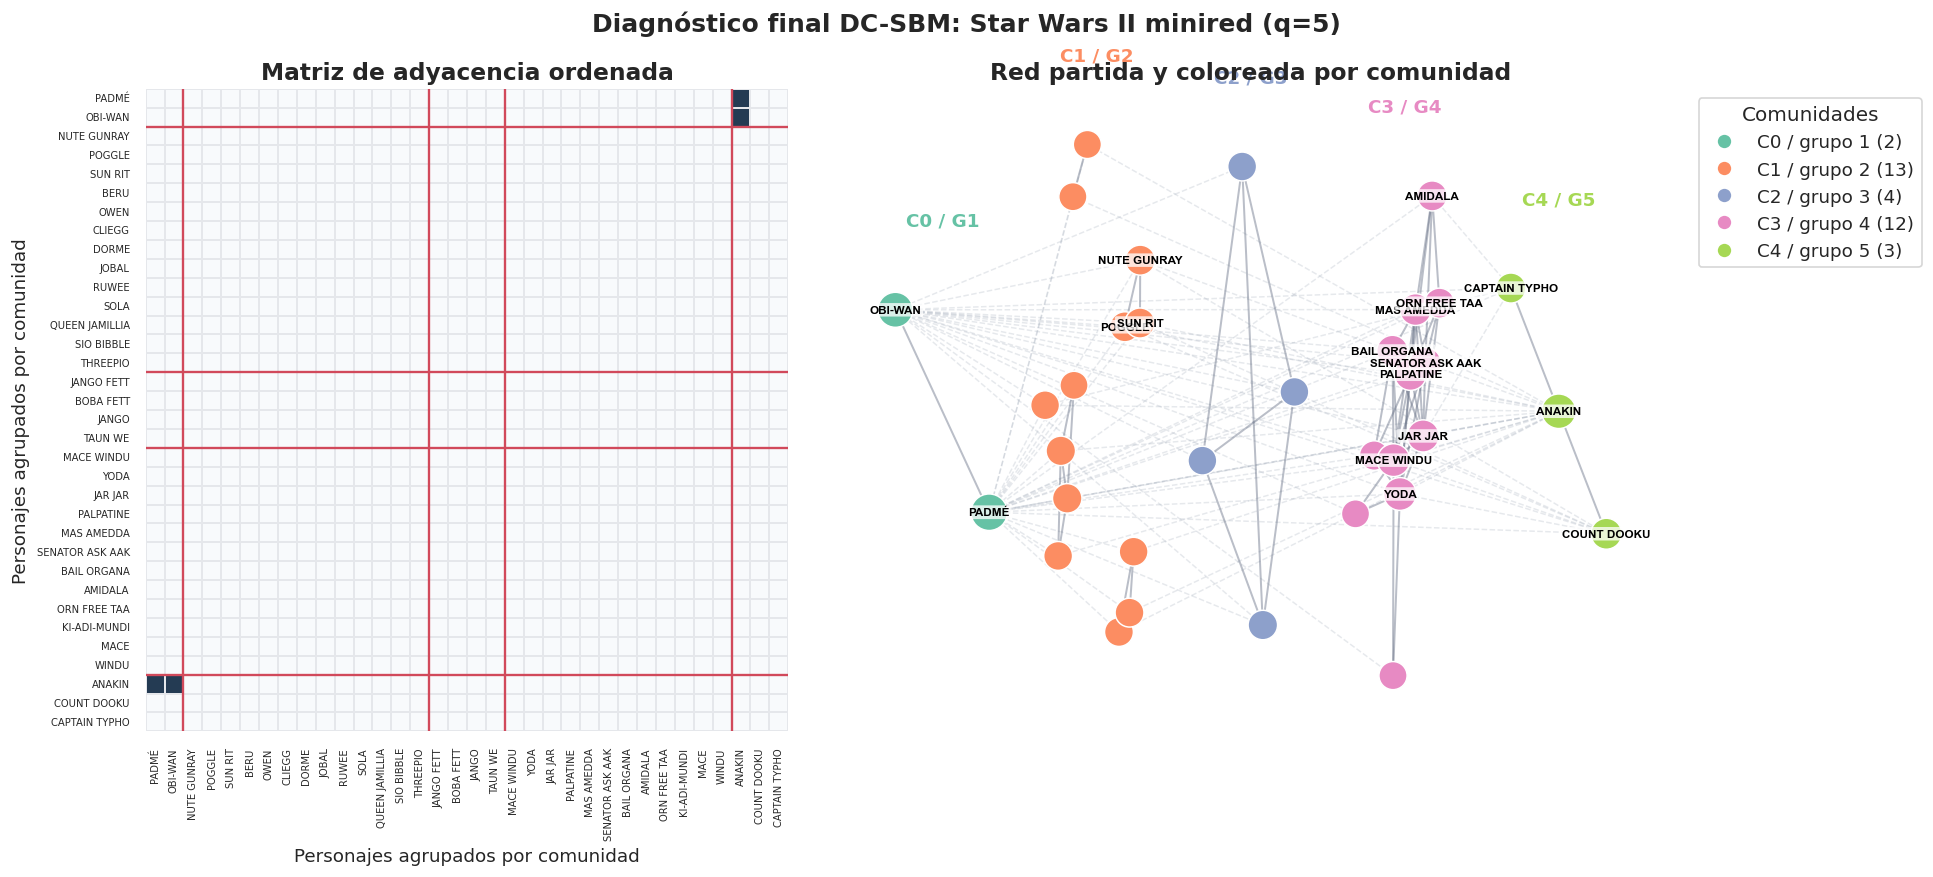

In [12]:
# ============================================================
# 12. Matriz de adyacencia y red partida por comunidades
# ============================================================
def partition_layout(Gx: nx.Graph, fit: DCSBMFit) -> dict[str, tuple[float, float]]:
    pos = {}
    centers = np.linspace(-1.7 * (fit.q - 1), 1.7 * (fit.q - 1), fit.q) if fit.q > 1 else np.array([0.0])
    for c, center_x in enumerate(centers):
        nodes = [node for node in fit.communities[c] if node in Gx]
        sub = Gx.subgraph(nodes)
        if len(nodes) == 1:
            local = {nodes[0]: np.array([0.0, 0.0])}
        else:
            local = nx.spring_layout(sub, seed=RANDOM_SEED + 37 * c, k=0.9)
        spread = 0.95 + 0.06 * np.sqrt(max(1, len(nodes)))
        for node, coords in local.items():
            pos[node] = (center_x + spread * coords[0], spread * coords[1])
    return pos


def plot_adjacency_and_partition(Gx: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    nodes = ordered_nodes_for_plot(Gx, fit)
    A = nx.to_numpy_array(Gx, nodelist=nodes, dtype=int)
    labels = [fit.labels[node] for node in nodes]
    colors = community_color_map(fit)
    node_colors = [colors[fit.labels[node]] for node in Gx.nodes()]
    node_sizes = [190 + 55 * np.sqrt(Gx.degree(node)) for node in Gx.nodes()]
    boundaries = np.cumsum([sum(label == c for label in labels) for c in range(fit.q)])[:-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7.2), gridspec_kw={"width_ratios": [1.05, 1.35]}, constrained_layout=True)
    ax_adj, ax_net = axes

    sns.heatmap(
        A,
        ax=ax_adj,
        cmap=sns.color_palette(["#F8FAFC", "#243B53"], as_cmap=True),
        cbar=False,
        square=True,
        linewidths=0.08,
        linecolor="#E5E7EB",
        xticklabels=nodes,
        yticklabels=nodes,
    )
    for boundary in boundaries:
        ax_adj.axhline(boundary, color="#D1495B", linewidth=1.4)
        ax_adj.axvline(boundary, color="#D1495B", linewidth=1.4)
    ax_adj.set_title("Matriz de adyacencia ordenada")
    ax_adj.set_xlabel("Personajes agrupados por comunidad")
    ax_adj.set_ylabel("Personajes agrupados por comunidad")
    ax_adj.tick_params(axis="x", labelrotation=90, labelsize=6)
    ax_adj.tick_params(axis="y", labelsize=6)

    pos = partition_layout(Gx, fit)
    external_edges = [(u, v) for u, v in Gx.edges() if fit.labels[u] != fit.labels[v]]
    internal_edges = [(u, v) for u, v in Gx.edges() if fit.labels[u] == fit.labels[v]]
    nx.draw_networkx_edges(Gx, pos, edgelist=external_edges, ax=ax_net, edge_color="#A7B0BE", alpha=0.28, width=0.9, style="dashed")
    nx.draw_networkx_edges(Gx, pos, edgelist=internal_edges, ax=ax_net, edge_color="#667085", alpha=0.45, width=1.2)
    nx.draw_networkx_nodes(Gx, pos, ax=ax_net, node_color=node_colors, node_size=node_sizes, edgecolors="white", linewidths=0.9)

    label_threshold = max(3, np.percentile([d for _, d in Gx.degree()], 65))
    top_labels = {node: node for node, degree in Gx.degree() if degree >= label_threshold}
    nx.draw_networkx_labels(
        Gx,
        pos,
        labels=top_labels,
        ax=ax_net,
        font_size=7,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.76},
    )
    for c, nodes_c in fit.communities.items():
        present = [node for node in nodes_c if node in pos]
        if present:
            xs = [pos[node][0] for node in present]
            ys = [pos[node][1] for node in present]
            ax_net.text(float(np.mean(xs)), float(max(ys) + 0.35), f"C{c} / G{c+1}", ha="center", va="bottom", fontsize=11, fontweight="bold", color=colors[c])

    handles = [
        Line2D([0], [0], marker="o", color="w", label=f"C{c} / grupo {c+1} ({len(fit.communities[c])})",
               markerfacecolor=colors[c], markeredgecolor="white", markersize=9)
        for c in range(fit.q)
    ]
    ax_net.legend(handles=handles, title="Comunidades", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
    ax_net.set_title("Red partida y coloreada por comunidad")
    ax_net.axis("off")

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


plot_adjacency_and_partition(G, fit_full, f"Diagnóstico final DC-SBM: Star Wars II completa (q={fit_full.q})", "final_adyacencia_y_red_partida_G.png")
plot_adjacency_and_partition(G_mini, fit_mini, f"Diagnóstico final DC-SBM: Star Wars II minired (q={fit_mini.q})", "final_adyacencia_y_red_partida_G_mini.png")

## 11. Conclusión breve

El DC-SBM no debe leerse como una técnica que siempre busca grupos cerrados. En redes narrativas, la partición puede mezclar:

$$
\text{subtramas densas}
\quad+\quad
\text{personajes puente}
\quad+\quad
\text{bloques de rol que se conectan entre sí}.
$$

La clave es mirar $M$ y $\hat\Omega$. Si una comunidad tiene alta diagonal, se comporta como subtrama cerrada. Si el valor dominante está fuera de la diagonal, el modelo está detectando una relación entre dos partes de la historia.